# MODELOS DE REDES

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import jarque_bera
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import SimpleRNN, LSTM, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error

# Importaciones de bibliotecas estándar
import os
import re
import sys
import math
import datetime
import warnings

# Importaciones de terceros
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from joblib import dump, load
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

# Importaciones de TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM, SimpleRNN
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K


# Importaciones de sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Model

from statsmodels.tsa.stattools import q_stat
from statsmodels.tsa.api import acf

from tensorflow.keras.callbacks import ModelCheckpoint
import os
from joblib import dump, load

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import Callback

In [2]:
# Load the dataset
file_path = 'river_aire_discharge_timeseries.csv'
data = pd.read_csv(file_path)

# Display the first few rows to understand the structure
data.head()
# Check if 'discharge_armley' exists in the columns
'discharge_armley' in data.columns


True

6/6 [==============================] - 0s 3ms/step


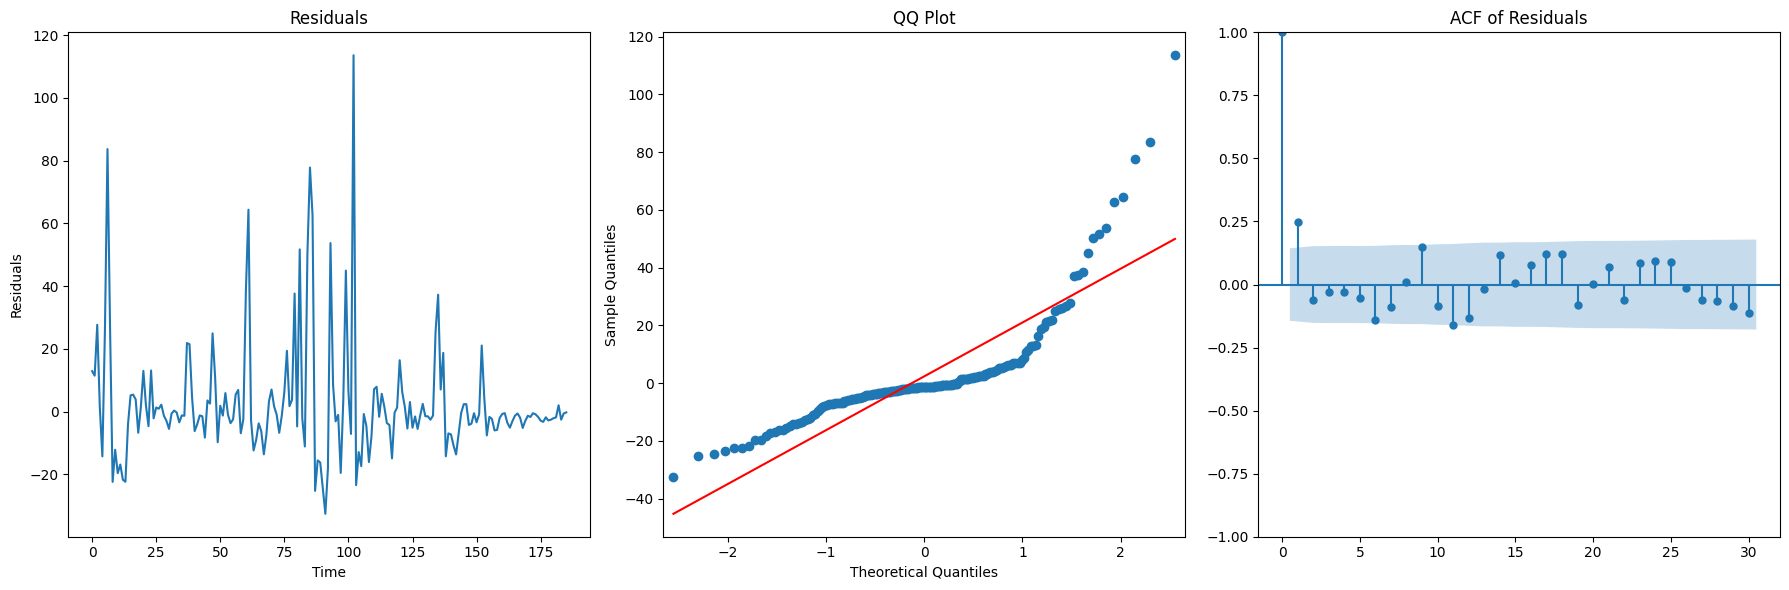

  Model       MAPE        MAE       RMSE         MSE        R2  \
0   RNN  32.327823   9.281355  16.750847  280.590882  0.585051   
1  LSTM  26.191369   8.998524  16.610843  275.920109  0.591959   
2   MLP  33.627859  10.320404  18.793833  353.208156  0.477662   

                                     Best Parameters  
0  {'units': 50, 'learning_rate': 0.01, 'batch_si...  
1  {'units': 50, 'learning_rate': 0.001, 'batch_s...  
2  {'units': 100, 'learning_rate': 0.001, 'batch_...  
Ljung-Box Test p-value: 0.00457358971209648
Jarque-Bera Test p-value: 1.0927847573642137e-215


In [3]:
#preparar Datos
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data.set_index('Date', inplace=True)

#seleccionar columna de estudio
ts_data = data[['discharge_armley']].dropna()

# Escalar datos
scaler = MinMaxScaler(feature_range=(0, 1))
ts_scaled = scaler.fit_transform(ts_data)

# funcion para crear ventanas de entrenamiento de 30 días.
def create_sequences(data, sequence_length=30):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

# preparar ventana de entrenamientos
sequence_length = 30
X, y = create_sequences(ts_scaled, sequence_length)

# Dividir dataset training (70%), validation (15%) and testing (15%)
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))
X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

# Funcion de construcción de modelos
def build_model(model_type, input_shape, units=50, learning_rate=0.001, dropout_rate=0.2):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(units, input_shape=input_shape))
    elif model_type == 'LSTM':
        model.add(LSTM(units, input_shape=input_shape))
    elif model_type == 'MLP':
        model.add(Dense(units, activation='relu', input_shape=(input_shape[0],)))
    model.add(Dropout(dropout_rate))  # Add dropout layer for regularization
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Busqueda por rejilla optimización
units_options = [50, 100]
learning_rate_options = [0.001, 0.01]
batch_size_options = [16, 32]
dropout_rate_options = [0.2, 0.3]

# Inicializar dataframe de errores
results = {
    "Model": [],
    "MAPE": [],
    "MAE": [],
    "RMSE": [],
    "MSE": [],
    "R2": [],
    "Best Parameters": []
}

# funcion para evaluar modelo según las métricas definidas
def evaluate_model(model, X_test, y_test, name, best_params):
   
    y_pred = model.predict(X_test)
    y_pred_inverse = scaler.inverse_transform(y_pred)
    y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # Metricas de evaluación 
    mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
    mse = mean_squared_error(y_test_inverse, y_pred_inverse)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_inverse, y_pred_inverse)
    mape = np.mean(np.abs((y_test_inverse - y_pred_inverse) / y_test_inverse)) * 100
    
    # Append results
    results['Model'].append(name)
    results['MAPE'].append(mape)
    results['MAE'].append(mae)
    results['RMSE'].append(rmse)
    results['MSE'].append(mse)
    results['R2'].append(r2)
    results['Best Parameters'].append(best_params)

# Busqueda por rejilla para mejores parámetros
models = ['RNN', 'LSTM', 'MLP']
for model_type in models:
    best_mse = float("inf")
    best_params = {}
    
    for units in units_options:
        for lr in learning_rate_options:
            for batch_size in batch_size_options:
                for dropout in dropout_rate_options:
                    input_shape = (X_train.shape[1], X_train.shape[2]) if model_type != 'MLP' else (X_train.shape[1],)
                    model = build_model(model_type, input_shape, units, lr, dropout)
                    
                    # Fit model using training and validation data
                    early_stopping = EarlyStopping(monitor='val_loss', patience=5)
                    model.fit(X_train, y_train, epochs=50, batch_size=batch_size, 
                              validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
                    
                    # Evaluate on validation set
                    y_pred_val = model.predict(X_val)
                    mse = mean_squared_error(y_val, y_pred_val)
                    
                    # Save best model
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {
                            "units": units,
                            "learning_rate": lr,
                            "batch_size": batch_size,
                            "dropout_rate": dropout
                        }
                        best_model = model

    # Evaluate and store results for the best model
    evaluate_model(best_model, X_test, y_test, model_type, best_params)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Now let's generate the plots for residual analysis
y_pred_scaled = best_model.predict(X_test)
residuals = scaler.inverse_transform(y_test.reshape(-1, 1)) - scaler.inverse_transform(y_pred_scaled)

# Generate plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Residual plot
axes[0].plot(residuals)
axes[0].set_title("Residuals")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Residuals")

# QQ plot
qqplot(residuals.flatten(), line='s', ax=axes[1])
axes[1].set_title("QQ Plot")

# ACF plot
plot_acf(residuals.flatten(), lags=30, ax=axes[2])
axes[2].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()

# Apply statistical tests
_, ljung_box_pval = q_stat(acf(residuals, fft=True, nlags=30)[1:], len(residuals))
_, jarque_bera_pval = jarque_bera(residuals)

# Show the results DataFrame and statistical test p-values
print(results_df)
print("Ljung-Box Test p-value:", ljung_box_pval.mean())
print("Jarque-Bera Test p-value:", jarque_bera_pval)



# BESN

In [18]:
# Sinteis del modelo
image_path = "image.png"
display(Image(filename=image_path))

NameError: name 'Image' is not defined

In [19]:
file_path = 'river_aire_discharge_timeseries.csv'
df = pd.read_csv(file_path)

# Copiar la columna 'Price' a una nueva variable
df = df['discharge_armley'].copy()

# Crear el escalador
scaler = MinMaxScaler(feature_range=(0, 1))

# Escalar los datos
df_scaled = scaler.fit_transform(df.values.reshape(-1, 1)).flatten()

# Convertir a DataFrame si es necesario
df_discharge_scaled = pd.DataFrame(df_scaled, columns=['discharge_scaled'])

print(df_discharge_scaled)

      discharge_scaled
0             0.021887
1             0.033704
2             0.037096
3             0.033863
4             0.026868
...                ...
1259          0.007684
1260          0.025066
1261          0.010970
1262          0.008691
1263          0.008320

[1264 rows x 1 columns]


# Pliego BESN

In [8]:
tfd = tfp.distributions

# 1. Definición de la Echo State Layer
class EchoStateLayer(Layer):
    def __init__(self, units, spectral_radius=0.9, leaky_rate=1.0, **kwargs): 
        #spectral_radius: indica que tán dinámico es el reservorio. 
        #Valores bajos hacen que el reservorio sea mas estable, 
        # y por lo tanto poca memoria para recordar patrones lejanos
        super(EchoStateLayer, self).__init__(**kwargs)
        self.units = units
        self.spectral_radius = spectral_radius
        self.leaky_rate = leaky_rate

def build(self, input_shape):
    # Crear pesos del reservorio
    initial_weights = np.random.uniform(-0.5, 0.5, size=(self.units, self.units)).astype(np.float32)
    max_eigenvalue = np.max(np.abs(np.linalg.eigvals(initial_weights)))
    self.reservoir_weights = self.add_weight(
        shape=(self.units, self.units),
        initializer=tf.keras.initializers.Constant(initial_weights / max_eigenvalue * self.spectral_radius),
        trainable=False,
        name='reservoir_weights'
    )
    
    self.input_weights = self.add_weight(
        shape=(input_shape[-1], self.units),
        initializer=tf.keras.initializers.RandomUniform(-0.5, 0.5),
        trainable=False,
        name='input_weights'
    )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        time_steps = tf.shape(inputs)[1]
        state = tf.zeros((batch_size, self.units))

        # Utilizar tf.TensorArray para gestionar estados sin problemas de grafo
        states = tf.TensorArray(dtype=tf.float32, size=time_steps)

        for t in range(time_steps):
            current_input = inputs[:, t, :]
            state_update = tf.nn.tanh(tf.matmul(current_input, self.input_weights) + tf.matmul(state, self.reservoir_weights))
            state = (1 - self.leaky_rate) * state + self.leaky_rate * state_update
            states = states.write(t, state)

        return states.stack()

# 2. Definición de la capa densa con regularización bayesiana
class BayesianDense(Layer):
    def __init__(self, units, prior_stddev, **kwargs):
        super(BayesianDense, self).__init__(**kwargs)
        self.units = units
        self.prior_stddev = prior_stddev

    def build(self, input_shape):
        self.weight_prior = tfd.Normal(loc=0., scale=self.prior_stddev)
        self.bias_prior = tfd.Normal(loc=0., scale=self.prior_stddev)

        self.weight_posterior = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True
        )
        self.bias_posterior = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        weight_distribution = tfd.Normal(loc=self.weight_posterior, scale=self.prior_stddev)
        bias_distribution = tfd.Normal(loc=self.bias_posterior, scale=self.prior_stddev)
        weights = weight_distribution.sample()
        bias = bias_distribution.sample()
        return tf.matmul(inputs, weights) + bias

# 3. Definir la función de pérdida personalizada con regularización bayesiana
def bayesian_loss(beta, alpha):
    def loss(y_true, y_pred):
        # Asegurar que tengan la misma forma
        y_true = tf.reshape(y_true, [-1, 1])
        y_pred = tf.reshape(y_pred, [-1, 1])
        E_D = tf.reduce_mean(tf.square(y_pred - y_true))  # Error de datos
        E_W = tf.reduce_sum(tf.square(y_pred))            # Regularización de pesos
        return beta * E_D + alpha * E_W #Beta le da mas importancia el error en los datos y alpha le da más importancia al error en los pesos iniciales
    return loss


def create_bayesian_ESN(input_shape, reservoir_units, output_dim, prior_stddev, alpha, beta):
    inputs = Input(shape=input_shape)
    esn = EchoStateLayer(reservoir_units, spectral_radius=0.9, leaky_rate=1.0)(inputs)
    # Cambiado: Tomar el último estado en lugar del promedio
    esn = esn[:, -1, :]  
    outputs = BayesianDense(output_dim, prior_stddev)(esn)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss=bayesian_loss(beta=beta, alpha=alpha))
    return model

In [20]:
def create_sliding_windows(data, window_sizes, step_size, taus): # Función para crear las ventanas de tiempo
    result_dict = {}  # Diccionario para almacenar los DataFrames por `window_size`
    
    for w in window_sizes:    
        all_combined_dfs = []  # Para almacenar resultados combinados para el tamaño de ventana actual

        for t in taus:
            X, y = [], []
            for i in range(0, len(data) - (w + t), step_size):
                # Ventana de entrada
                X.append(data[i:i + w])
                
                # Extraer el valor específico de `tau` pasos adelante
                future_value = data[i + w + t - 1]  # -1 para índice cero
                y.append([future_value])  # Guarda solo el valor correspondiente a `tau`
            
            # Convertir X e y en DataFrames
            df_X = pd.DataFrame(np.array(X).squeeze())  # Asegura que sea un array 2D (n, w)
            df_y = pd.DataFrame(y, columns=[f'Tau_{t}'])  # Solo la columna para el tau actual
            
            # Combinar los DataFrames de X e y
            df_combined = pd.concat([df_X, df_y], axis=1)
            all_combined_dfs.append(df_combined)
        
        # Combina todos los resultados para el tamaño de ventana actual
        final_df = pd.concat(all_combined_dfs, axis=0).reset_index(drop=True)
        
        # Guarda en el diccionario
        result_dict[f'Window_{w}'] = final_df
    
    return result_dict

In [21]:
def segment_data_by_window(df, train_size, val_size, test_size): # Función para segmentar los datos en train, validation y test
    train_data, val_data, test_data = [], [], []
    i = 0
    while i + train_size + val_size + test_size <= len(df):
        # Segmento de entrenamiento
        train_data.append(df.iloc[i:i + train_size])
        # Segmento de validación
        val_data.append(df.iloc[i + train_size:i + train_size + val_size])
        # Segmento de prueba
        test_data.append(df.iloc[i + train_size + val_size:i + train_size + val_size + test_size])
        
        # Mover el índice al siguiente bloque
        i += train_size + val_size + test_size
    
    # Concatenar los segmentos de datos
    train_data = pd.concat(train_data).reset_index(drop=True)
    val_data = pd.concat(val_data).reset_index(drop=True)
    test_data = pd.concat(test_data).reset_index(drop=True)

    return train_data, val_data, test_data,df


In [22]:
class ManualR2Callback(Callback): #Calculo del r2 como métrica personalizada e incluirse en el History. 
    def __init__(self, X_val, y_val):
        super(ManualR2Callback, self).__init__()
        self.X_val = X_val
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        val_predictions = self.model.predict(self.X_val).flatten()
        val_r2 = r2_score(self.y_val, val_predictions)
        print(f"Epoch {epoch + 1}: Validation R2 Score = {val_r2:.4f}")

In [51]:
def select_best_model(model, model_type, neurons, dropout, batch_size, epochs, X_train, y_train, X_val, y_val, X_test, y_test, return_history, window_size, tau,serie):
    # Crear subdirectorio para el tamaño de ventana específico
    model_dir = f'modelos_{serie}/models_window_{window_size}_tau_{tau}'
    os.makedirs(model_dir, exist_ok=True)

    # Nombre lógico del archivo basado en los parámetros del modelo
    base_filename = f'{model_type}_{neurons}neurons_{dropout}dropout_batch{batch_size}_window{window_size}_tau{tau}'
    model_filename = os.path.join(model_dir, f'{base_filename}_best_model.keras')
    history_filename = os.path.join(model_dir, f'{base_filename}_history.joblib')
    
    # Callback para guardar el mejor modelo
    save_best = ModelCheckpoint(model_filename, monitor='val_mean_squared_error', verbose=1,
                                save_best_only=True, mode='min', save_weights_only=False)
    
    # Callback para calcular R2 manual al final de cada época
    manual_r2_callback = ManualR2Callback(X_val, y_val)
    
    # Variable para decidir si entrenar un nuevo modelo
    load_new_model = True
    best_val_mse = float('inf')
    existing_epochs = 0

    # Cargar historial previo si existe y verificar el val_mean_squared_error y las épocas
    if os.path.exists(history_filename):
        history_data = load(history_filename)
        existing_epochs = len(history_data['loss'])
        if 'val_mean_squared_error' in history_data:
            best_val_mse = min(history_data['val_mean_squared_error'])

        # Comprobar si el modelo existente tiene mejor val_mean_squared_error y mayor o igual épocas
        if best_val_mse <= history_data['val_mean_squared_error'][-1] and existing_epochs >= epochs:
            print(f"Modelo previo con mejor val_mean_squared_error ({best_val_mse}) y más épocas ({existing_epochs}). No se reemplazará.")
            load_new_model = False
        else:
            print(f"Se entrenará con {epochs} y actualizará si mejora el rendimiento.")

    # Entrenar y guardar el modelo si se requiere uno nuevo
    if load_new_model:
        # Entrenar el modelo y guardar el historial
        history = model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs,
                            verbose=2, callbacks=[save_best, manual_r2_callback], validation_data=(X_val, y_val),
                            shuffle=True)
        
        # Guardar el historial en el archivo .joblib
        history_data = history.history
        
        # Evaluar el mejor modelo en el conjunto de prueba
        test_results = model.evaluate(X_test, y_test, verbose=0)
        test_metrics = {f'test_{metric}': value for metric, value in zip(model.metrics_names, test_results)}
        
        # Agregar métricas de prueba al historial
        for metric, value in test_metrics.items():
            history_data[metric] = [value]
        
        # Guardar el historial con las métricas de prueba
        dump(history_data, history_filename)
        print(f"El entrenamiento se ha completado y el historial se guardó en '{history_filename}'")

    # Verificar y cargar el mejor modelo guardado
    if os.path.exists(model_filename):
        print(f"El mejor modelo guardado está en '{model_filename}'")
        best_model = load_model(model_filename)
    else:
        print("No se encontró un modelo previo con mejor val_mean_squared_error.")
        best_model = model

    # Retornar el mejor modelo y el historial, si es necesario
    if return_history:
        return best_model, history_data
    else:
        return best_model

In [52]:
window_sizes = [7]  # Tamaño de ventana restringido por limitaciones computacionales
step_size = 1
predictions_dict = {}
error_dict = {}
history_BESN = {}

# Diccionarios para almacenar matrices y predicciones multivariadas
trainX_matrices = {}
trainY_matrices = {}
valX_matrices = {}
valY_matrices = {}
testX_matrices = {}
testY_matrices = {}
predictions_multivariate_discharge_scaled = {'BESN': {}}

# Inicialización de predicciones para todos los valores de tau (1 a 28)
for www in window_sizes:
    for model_name in ['BESN']:
        predictions_multivariate_discharge_scaled[model_name][www] = {}
        for tau in range(1, 29):  # Configurar todos los tau desde el inicio
            predictions_multivariate_discharge_scaled[model_name][www][f'Train_Pred_tau_{tau}'] = []
            predictions_multivariate_discharge_scaled[model_name][www][f'Val_Pred_tau_{tau}'] = []
            predictions_multivariate_discharge_scaled[model_name][www][f'Test_Pred_tau_{tau}'] = []

# Inicialización de matrices de entrenamiento, validación y prueba para cada ventana
for www in window_sizes:
    trainX_matrices[www] = {}
    trainY_matrices[www] = {}
    valX_matrices[www] = {}
    valY_matrices[www] = {}
    testX_matrices[www] = {}
    testY_matrices[www] = {}
    history_BESN[www] = {}

    best_model_BESN = None  # Variable para almacenar el mejor modelo

    for iii in range(1, 2):  # Crear ventanas deslizantes para cada tau
        result_dict = create_sliding_windows(data=df_discharge_scaled.values.flatten(), window_sizes=window_sizes, step_size=step_size, taus=[iii])
        train_data, val_data, test_data, df = segment_data_by_window(result_dict[f'Window_{www}'], train_size=2*www, val_size=www, test_size=www)
        
        # Asignar y transformar datos en matrices 3D (requeridas para el modelo)
        trainX = np.asarray(train_data.iloc[:, 0:www].values, dtype=float).reshape((len(train_data), www, 1))
        trainY = np.asarray(train_data.iloc[:, www].values, dtype=float).ravel()
        valX = np.asarray(val_data.iloc[:, 0:www].values, dtype=float).reshape((len(val_data), www, 1))
        valY = np.asarray(val_data.iloc[:, www].values, dtype=float).ravel()
        testX = np.asarray(test_data.iloc[:, 0:www].values, dtype=float).reshape((len(test_data), www, 1))
        testY = np.asarray(test_data.iloc[:, www].values, dtype=float).ravel()
        
        # Combinaciones de hiperparámetros restringidas para eficiencia
        alphas = [0.01, 0.1, 0.2]
        neurons_list = [200]
        prior_stddev = [1]
        betas = [0.1, 0.2, 0.5]
        dropout_rate = 0.2
        batch_size = 16
        
        for b in betas:
            for a in alphas:
                for neurons in neurons_list:
                    for t in prior_stddev:
                        print(f"Evaluando: Neuronas: {neurons}, Dropout: {dropout_rate}, Batchsize: {batch_size}")

                        # Crear y compilar el modelo BESN
                        model_BESN = create_bayesian_ESN(input_shape=(www, 1), reservoir_units=neurons, output_dim=1, prior_stddev=t, alpha=a, beta=b)
                        model_BESN.compile(optimizer='adam', loss='mse', metrics=[
                            'mean_absolute_error',            # MAE
                            'mean_absolute_percentage_error', # MAPE
                            'mean_squared_error'              # MSE
                        ])

                        # Seleccionar el mejor modelo y guardar con los parámetros configurados
                        best_model_BESN = select_best_model(model_BESN, 'BESN', neurons, dropout_rate,
                                                            batch_size, epochs=30, X_train=trainX, y_train=trainY,
                                                            X_val=valX, y_val=valY, X_test=testX, y_test=testY,
                                                            return_history=False, window_size=www, tau=iii, serie='discharge')

            # Almacenar las predicciones en el diccionario de predicciones
            for model_name, model in zip(['BESN'], [best_model_BESN]):
                predictions_multivariate_discharge_scaled[model_name][www][f'Train_Pred_tau_{iii}'] = model.predict(trainX).flatten().tolist()
                predictions_multivariate_discharge_scaled[model_name][www][f'Val_Pred_tau_{iii}'] = model.predict(valX).flatten().tolist()
                predictions_multivariate_discharge_scaled[model_name][www][f'Test_Pred_tau_{iii}'] = model.predict(testX).flatten().tolist()

        # Almacenar las matrices de datos para cada tau y ventana
        trainX_matrices[www][iii] = trainX
        trainY_matrices[www][iii] = trainY
        valX_matrices[www][iii] = valX
        valY_matrices[www][iii] = valY
        testX_matrices[www][iii] = testX
        testY_matrices[www][iii] = testY


Evaluando: Neuronas: 200, Dropout: 0.2, Batchsize: 16
Epoch 1/30

Epoch 1: val_mean_squared_error improved from inf to 1.11715, saving model to modelos_discharge/models_window_7_tau_1\BESN_200neurons_0.2dropout_batch16_window7_tau1_best_model.keras


ValueError: The following argument(s) are not supported with the native Keras format: ['options']

Este ciclo de iteración de modelos es el núcleo que compila, todas las demás funciones creadas anteriormente. La lógica de funcionamiento es la siguientes:

Para cada ventana en `window_size`, itera sobre los `tau` periodos requeridos. Barajando el dataframe, en ventanas de tamaño www a través de `create_sliding_windows(...)` con tau periodos, y luego crea un pliego con `segment_data_by_window(...)` que segmenta el data frame en train, val y test, que se usan para la función `select_best_model(...)`. Esta última se encuentra incluida en un ciclo de entrenamiento que varía los parámetros de los modelos(`neurons`,`dropout_rate` y`batch_size`), con el fin de utilizar la mejor combinación de parámetros para predecir el tau periodo. 

Una vez se encuentra el mejor modelo, se utiliza para construir lista de `predictions_multivariate_ret_acum[Model][www][...iii]` que alamacena la información de las predicciones, para posteriormente ser comparadas con los pliegos que quedan almacenados en matrices de forma `..._matrices[www][iii]`

Las épocas de entrenamiento se fijaron a discreción 30 periodos al ver que los modelos convergian a una minimo de error, como se visualizará mas adelante.

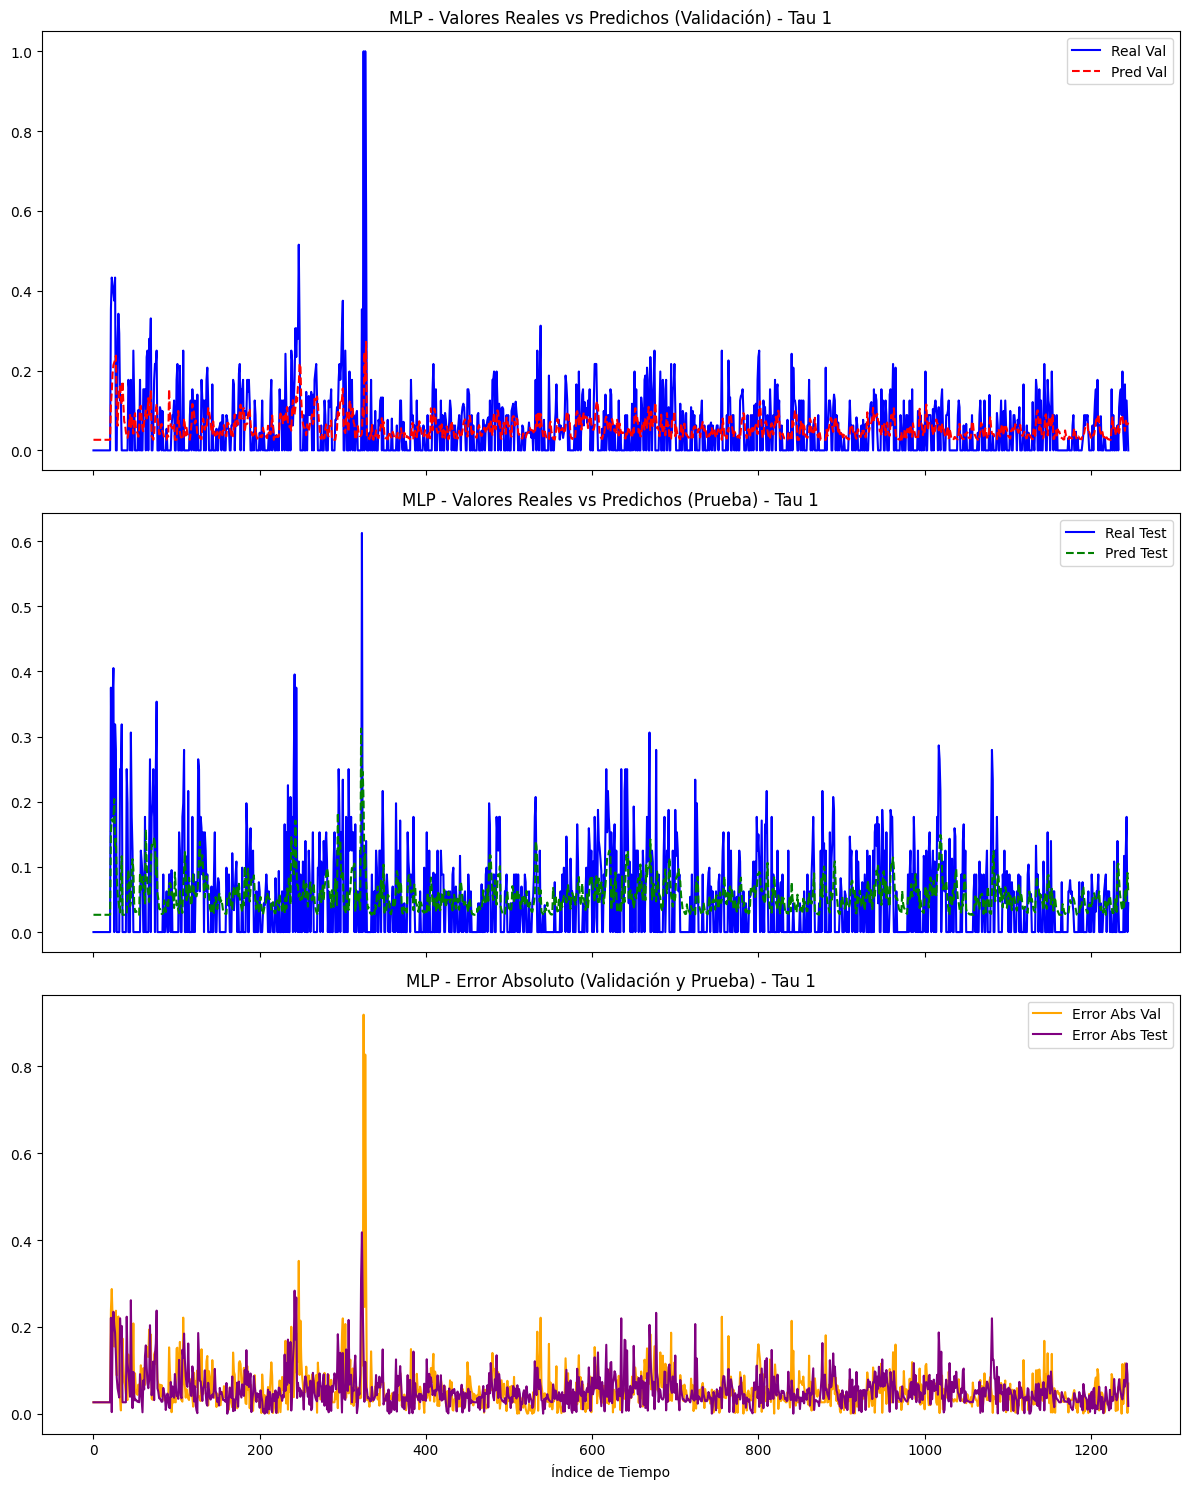

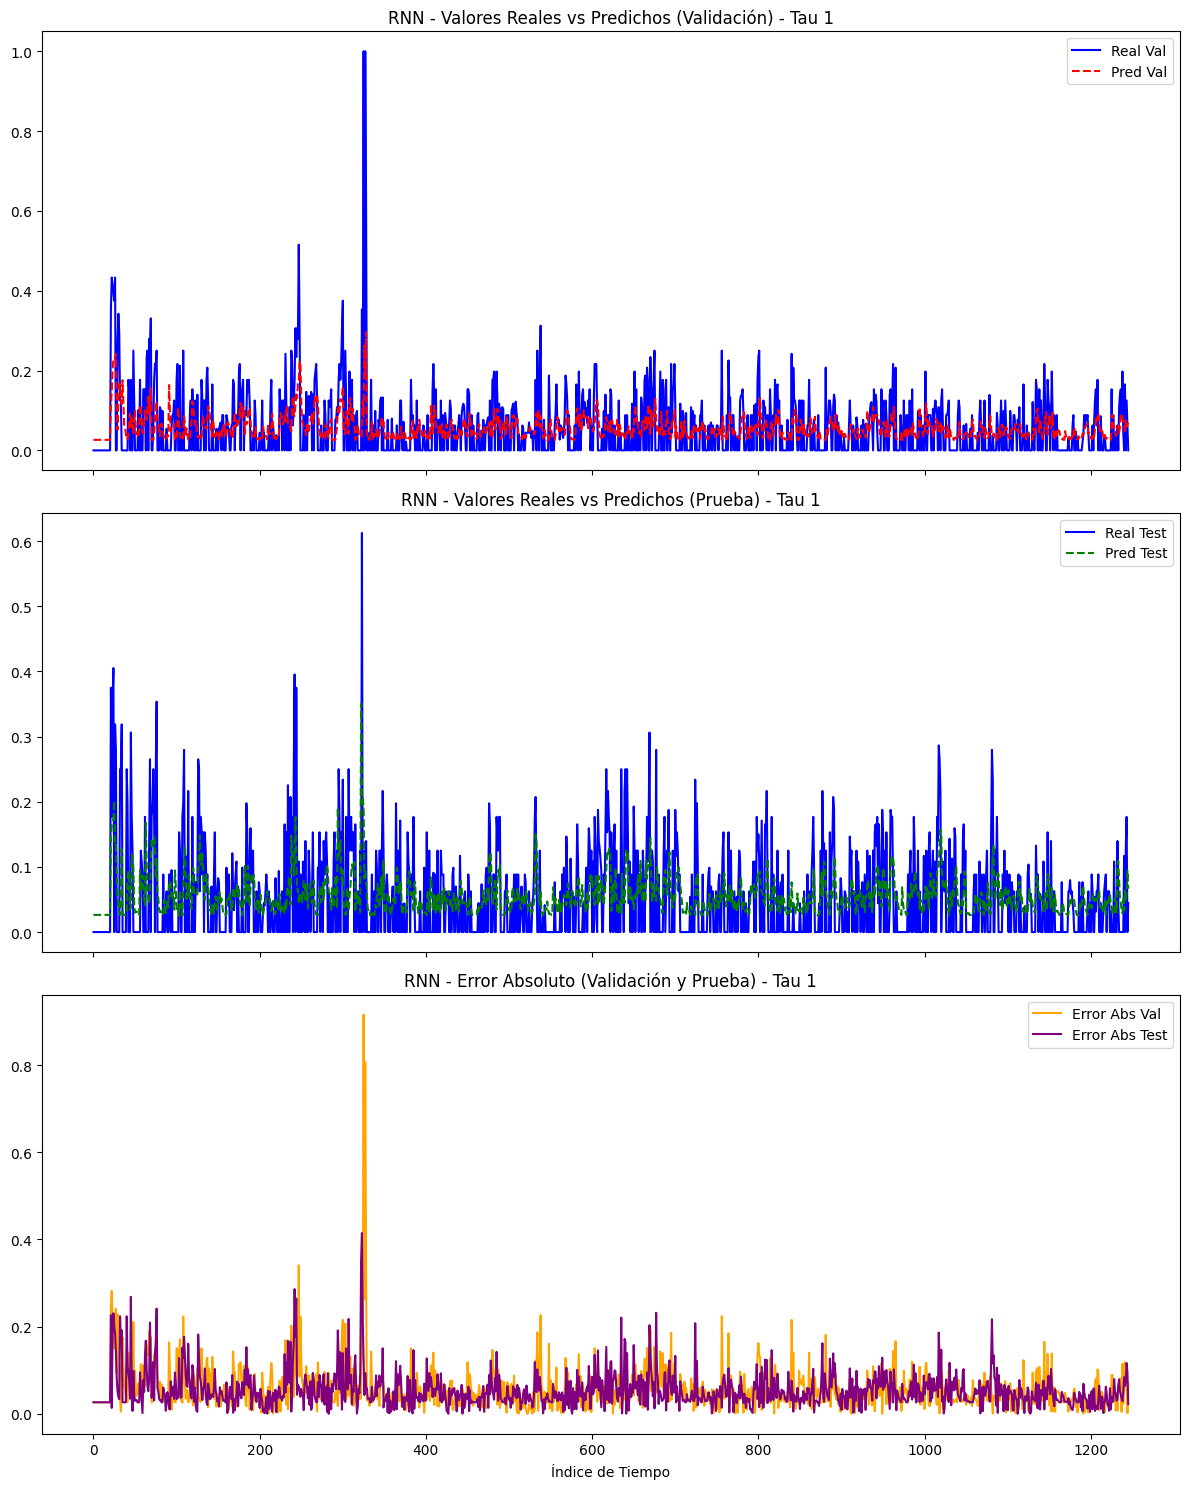

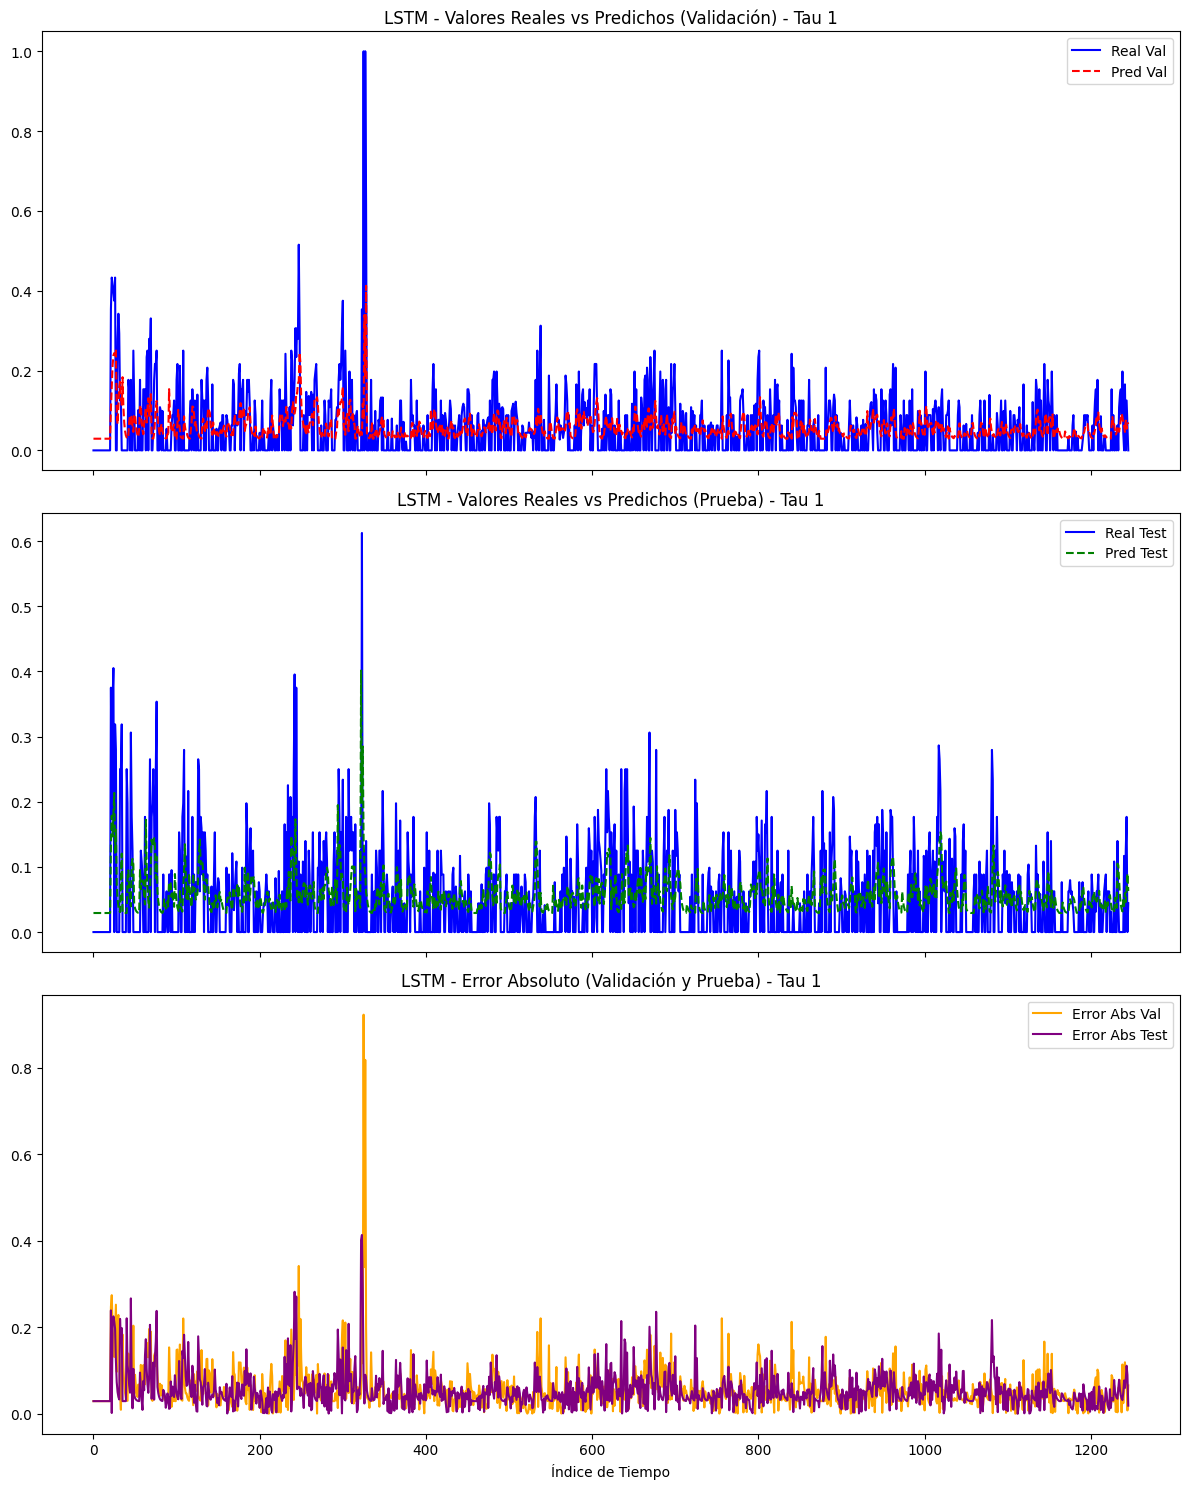

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def graficar_valores_y_errores(predictions_multivariate_discharge_scaled, trainY_matrices, valY_matrices, testY_matrices, window_size, modelo):
    """
    Genera gráficos para comparar los valores reales y predichos, junto con el error absoluto,
    para los conjuntos de validación y prueba.
    """
    for tau in range(1, 2):  # Cambia el rango de tau si tienes más ventanas
        # Obtener valores reales y predichos
        real_train = trainY_matrices[window_size][tau]
        real_val = valY_matrices[window_size][tau]
        real_test = testY_matrices[window_size][tau]
        
        pred_train = predictions_multivariate_discharge_scaled[modelo][window_size][f'Train_Pred_tau_{tau}']
        pred_val = predictions_multivariate_discharge_scaled[modelo][window_size][f'Val_Pred_tau_{tau}']
        pred_test = predictions_multivariate_discharge_scaled[modelo][window_size][f'Test_Pred_tau_{tau}']
        
        # Calcular el error absoluto
        error_abs_val = np.abs(np.array(real_val) - np.array(pred_val))
        error_abs_test = np.abs(np.array(real_test) - np.array(pred_test))
        
        # Configurar la gráfica
        fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
        
        # Gráfica 1: Valores Reales vs Predichos - Validación
        axes[0].plot(real_val, label='Real Val', color='blue')
        axes[0].plot(pred_val, label='Pred Val', color='red', linestyle='--')
        axes[0].set_title(f'{modelo} - Valores Reales vs Predichos (Validación) - Tau {tau}')
        axes[0].legend()
        
        # Gráfica 2: Valores Reales vs Predichos - Prueba
        axes[1].plot(real_test, label='Real Test', color='blue')
        axes[1].plot(pred_test, label='Pred Test', color='green', linestyle='--')
        axes[1].set_title(f'{modelo} - Valores Reales vs Predichos (Prueba) - Tau {tau}')
        axes[1].legend()

        # Gráfica 3: Error Absoluto para Validación y Prueba
        axes[2].plot(error_abs_val, label='Error Abs Val', color='orange')
        axes[2].plot(error_abs_test, label='Error Abs Test', color='purple')
        axes[2].set_title(f'{modelo} - Error Absoluto (Validación y Prueba) - Tau {tau}')
        axes[2].legend()
        
        plt.xlabel("Índice de Tiempo")
        plt.tight_layout()
        plt.show()

# Ejemplo de uso
# Para visualizar las gráficas para cada modelo y ventana
for modelo in ['MLP', 'RNN', 'LSTM']:
    graficar_valores_y_errores(predictions_multivariate_discharge_scaled, trainY_matrices, valY_matrices, testY_matrices, window_size=7, modelo=modelo)


Se realiza comparación de los errores absolutos en los conjuntos de validación y prueba evidenciando un comportamiento significativamente parecido en los respectivos pliegos. En cada uno de los modelos probados. 

#### item 4

C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\259735883.py:28: RuntimeWarning:

divide by zero encountered in divide

C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\259735883.py:47: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



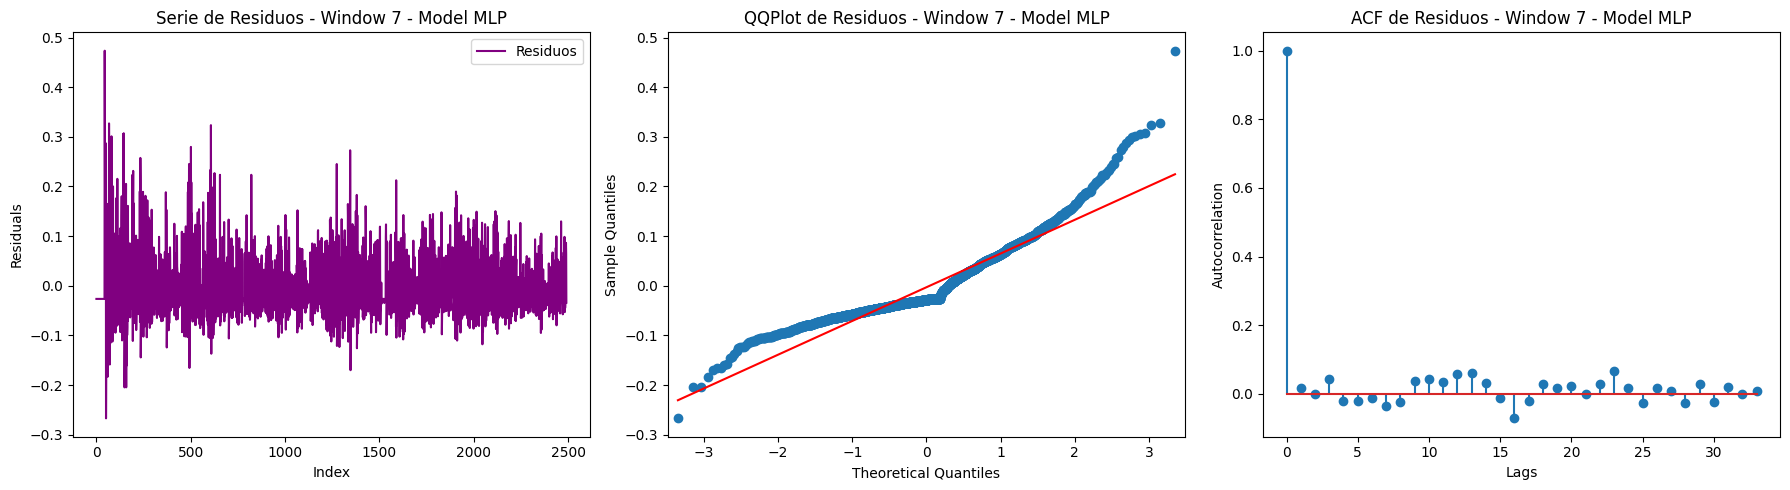

C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\259735883.py:28: RuntimeWarning:

divide by zero encountered in divide



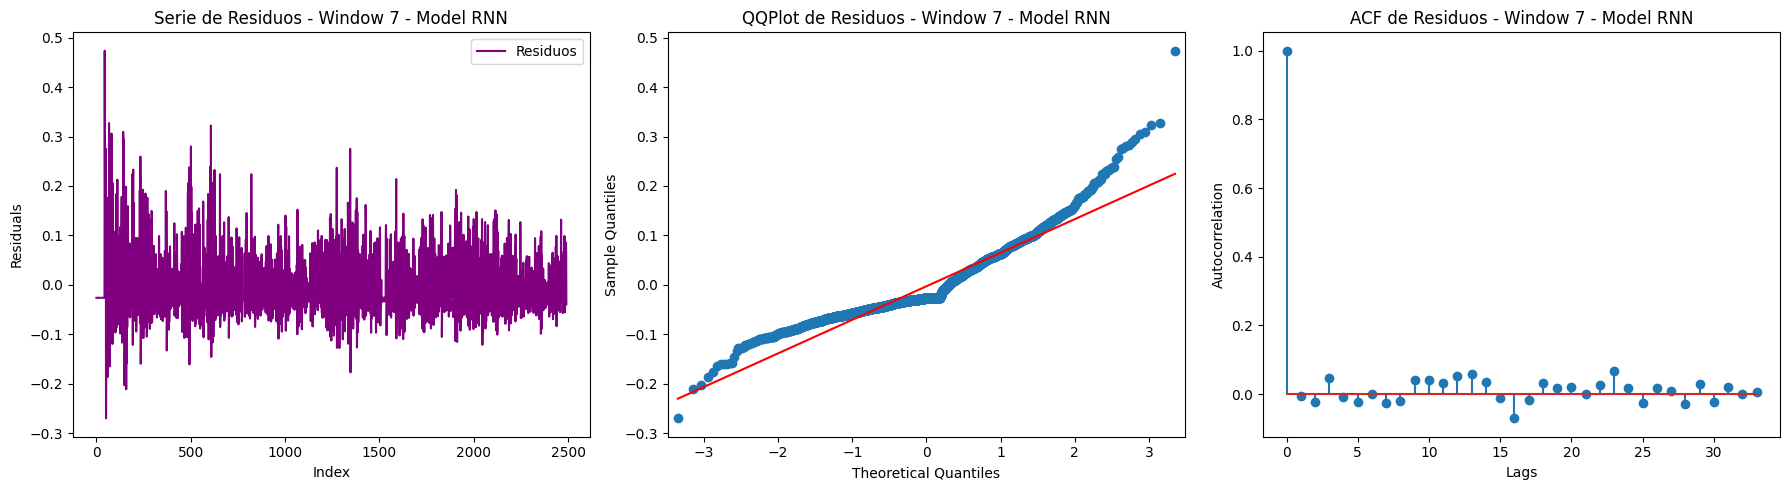

C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\259735883.py:28: RuntimeWarning:

divide by zero encountered in divide



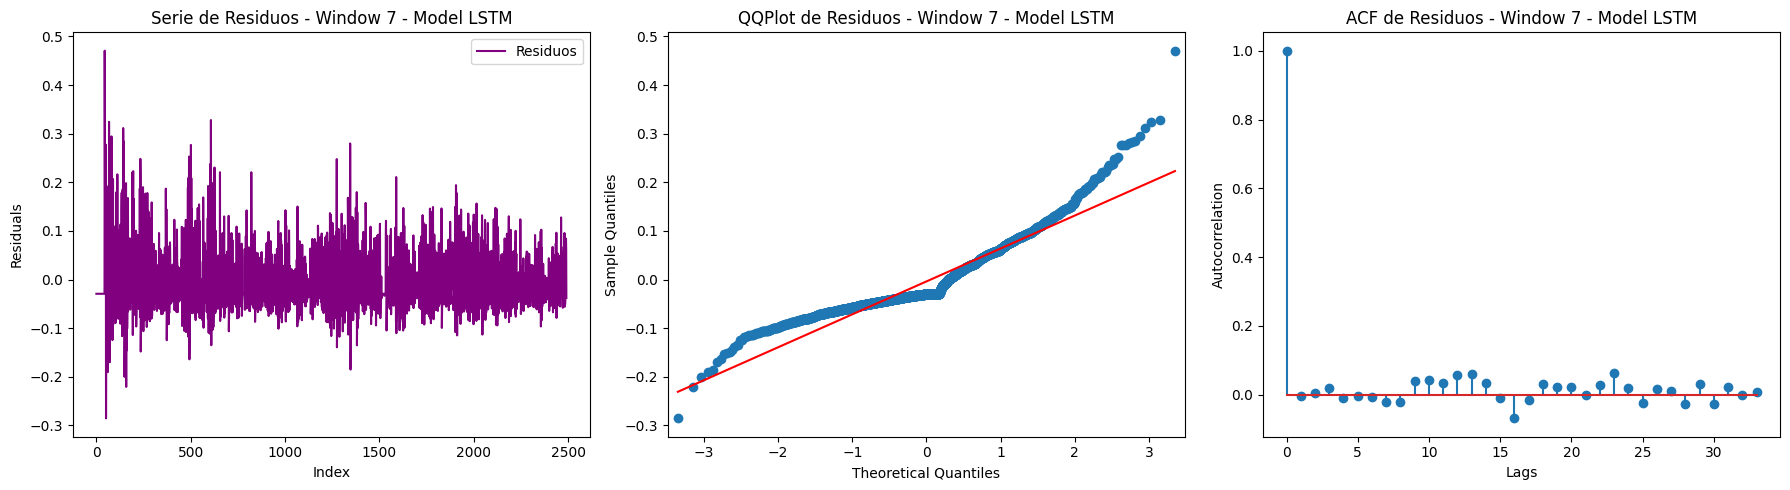

,Model,MAPE,MAE,RMSE,MSE,R2,LJung-Box (p-value),Jarque-Bera (p-value)
0,MLP,inf,0.054368,0.067976,0.004621,0.136803,0.023299,1.947832e-309
1,RNN,inf,0.054181,0.067948,0.004617,0.137522,0.037465,6.715824e-295
2,LSTM,inf,0.054524,0.067832,0.004601,0.140466,0.287858,8.053323e-301


In [ ]:
results_table = pd.DataFrame(columns=[ # Crear tabla para almacenar métricas y resultados de pruebas, incluyendo columna de modelo
    'Model', 'MAPE', 'MAE', 'RMSE', 'MSE', 'R2', 'LJung-Box (p-value)', 'Jarque-Bera (p-value)'
])

iii = 2
window_sizes = [7]
# Iterar a través de cada modelo, ventana y rango de tau
for model_name in ['MLP', 'RNN', 'LSTM']:
    for window in window_sizes:
        # Acumular valores reales y predichos de tau 1 a n en una sola lista
        combined_real_values = []
        combined_pred_values = []

        for tau in range(1, iii):  # Ajusta el rango de tau según tus necesidades
            # Acumular valores reales y predichos
            combined_real_values.extend(trainY_matrices[window][tau])
            combined_pred_values.extend(predictions_multivariate_discharge_scaled[model_name][window][f'Train_Pred_tau_{tau}'])

        # Convertir las listas acumuladas en arreglos numpy
        combined_real_values = np.array(combined_real_values)
        combined_pred_values = np.array(combined_pred_values)
        residuals = combined_real_values - combined_pred_values

        # Calcular métricas
        mae = mean_absolute_error(combined_real_values, combined_pred_values)
        mse = mean_squared_error(combined_real_values, combined_pred_values)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs(residuals / combined_real_values)) * 100
        r2 = r2_score(combined_real_values, combined_pred_values)

        # Pruebas de independencia (Ljung-Box) y normalidad (Jarque-Bera)
        lb_test = q_stat(acf(residuals, fft=True, nlags=10)[1:], len(residuals))[1][-1]
        jb_test = jarque_bera(residuals)[1]

        # Agregar los resultados a la tabla, incluyendo el nombre del modelo
        row = pd.DataFrame({
            'Model': [model_name],
            'MAPE': [mape],
            'MAE': [mae],
            'RMSE': [rmse],
            'MSE': [mse],
            'R2': [r2],
            'LJung-Box (p-value)': [lb_test],
            'Jarque-Bera (p-value)': [jb_test]
        })

        results_table = pd.concat([results_table, row], ignore_index=True)

        # Crear subplots para los gráficos en una misma figura
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Gráfico de la serie de residuos
        axes[0].plot(residuals, label='Residuos', color='purple')
        axes[0].set_title(f'Serie de Residuos - Window {window} - Model {model_name}')
        axes[0].set_xlabel('Index')
        axes[0].set_ylabel('Residuals')
        axes[0].legend()

        # QQ Plot de los residuos
        qqplot(residuals, line='s', ax=axes[1])
        axes[1].set_title(f'QQPlot de Residuos - Window {window} - Model {model_name}')

        # ACF de los residuos
        acf_values = acf(residuals, fft=True)
        axes[2].stem(acf_values)
        axes[2].set_title(f'ACF de Residuos - Window {window} - Model {model_name}')
        axes[2].set_xlabel('Lags')
        axes[2].set_ylabel('Autocorrelation')

        plt.tight_layout()
        plt.show()

# Mostrar la tabla completa con los resultados para cada modelo
display(results_table)


Se crea una tabla donde se resume para el residual en el conjunto de entrenamiento, los  scores obtenidos y agregue además las respectivas pruebas de hipóteis para independencia y normalidad. con una tabla de Pandas se construyen las columnas: MAPE, MAE, RMSE, MSE, R2, LJung-Box test (p-value), Jarque-Bera (p-value) y se agregan las figuras para Serie de residuos, QQPlot, ACF de residuos: 

Evidendiando lo siguiente: 

Todos los modelos en el conjunto de entrenamiento en este caso validado para una ventana de tamaño `www=7`, tienen un R2 muy cercano a 1, lo cual indica un posible sobre ajuste del modelo, que podría regularse si se usan dropout mayores en el proceso de entrenamiento. Las pruebas de independencia y normalidad de los residuos con un P_value=0.05, demuestran que los residuos no siguen una distribución normal y que existe una autocorrelación significativa entre los residuos de un periodo y otro. 

Esto ultimo también se evidencia en las gráficas de residuos QQ plot, que muestra que los datos no estár organizados con tendencia central, como se esperaría de la una distribución normal. y el ACF, muestra que hay Lags, de hasta 35 periodos en los que puede haber una correlación significativa. Adicionalmente, se podría sospechar que cada 7, 14,21,28 y 35, periodos de tiempo hay una estacionalidad marcada, esto podría deberse a la forma en la que está plegada la serie. 

Nota: el MAPE se descarta como métrica fiable de entrenamiento para series temporales que contienen valores reales de cero, dado que su forma de calaculo utiliza como denominador los valores reales. 

#### Item 5

In [ ]:
def calculate_scores(test_values, predictions):
    # Calcular métricas de error
    mae = mean_absolute_error(test_values, predictions)
    mse = mean_squared_error(test_values, predictions)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((test_values - predictions) / test_values)) * 100
    r2 = r2_score(test_values, predictions)
    
    # Prueba de Ljung-Box para independencia
    residuals = test_values - predictions
    lb_test = q_stat(acf(residuals, fft=True, nlags=40), len(residuals))[1][-1]  # Valor p

    return {
        "MAPE": mape,
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
        "R2": r2,
        "LJung-Box (p-value)": lb_test
    }

# Crear una lista para almacenar los resultados de cada modelo
results = []

# Modelos a evaluar
modelos = ['MLP', 'RNN', 'LSTM']
www = 7  # Tamaño de ventana usado en los datos
iii=2 #Tau periodo a revisar

# Concatenar los valores reales del conjunto de test en una sola serie
test_values = np.concatenate([testY_matrices[www][tau] for tau in range(1, iii)])

# Calcular y almacenar resultados para cada modelo
for model_name in modelos:
    # Concatenar las predicciones del conjunto de test en una sola serie
    predictions = np.concatenate([predictions_multivariate_discharge_scaled[model_name][www][f'Test_Pred_tau_{tau}'] for tau in range(1, iii)])
    
    # Calcular los puntajes y la prueba de Ljung-Box
    scores = calculate_scores(test_values, predictions)
    scores["Model"] = model_name

    # Agregar los resultados a la lista
    results.append(scores)

# Convertir la lista de resultados a un DataFrame
results_df = pd.DataFrame(results)

# Mostrar la tabla de resultados
results_df


C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\2555122796.py:6: RuntimeWarning:

divide by zero encountered in divide

C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\2555122796.py:6: RuntimeWarning:

divide by zero encountered in divide

C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\2555122796.py:6: RuntimeWarning:

divide by zero encountered in divide



,MAPE,MAE,RMSE,MSE,R2,LJung-Box (p-value),Model
0,inf,0.053799,0.067538,0.004561,0.120616,1.301341e-248,MLP
1,inf,0.053604,0.067615,0.004572,0.118609,3.927012e-249,RNN
2,inf,0.053887,0.067992,0.004623,0.108743,1.135766e-248,LSTM


Nota: el MAPE se descarta como métrica fiable de entrenamiento para series temporales que contienen valores reales de cero, dado que su forma de calaculo utiliza como denominador los valores reales. Por eso encontramos valores infinitos. 

Se crea una tabla donde se resume para el residual en el conjunto de entrenamiento, los  scores obtenidos y agregue además las respectivas pruebas de hipóteis para independencia y normalidad. con una tabla de Pandas se construyen las columnas: MAPE, MAE, RMSE, MSE, R2, LJung-Box test (p-value). 

Evidendiando lo siguiente: 

Todos los modelos en el conjunto de test en este caso validado para una ventana de tamaño `www=7`, tienen un R2 muy cercano a 1, lo cual nos indica una excelente capacidad de predecir patrones, que tiene las redes neuronales y la ventaja de utilizar pliegos que sigan de cerca el comportamiento de la serie. El modelo con mejor ajuste en esta etapa fue el RNN, con un MSE ligeramente por debajo de los demás modelos. 



#### Item 8 

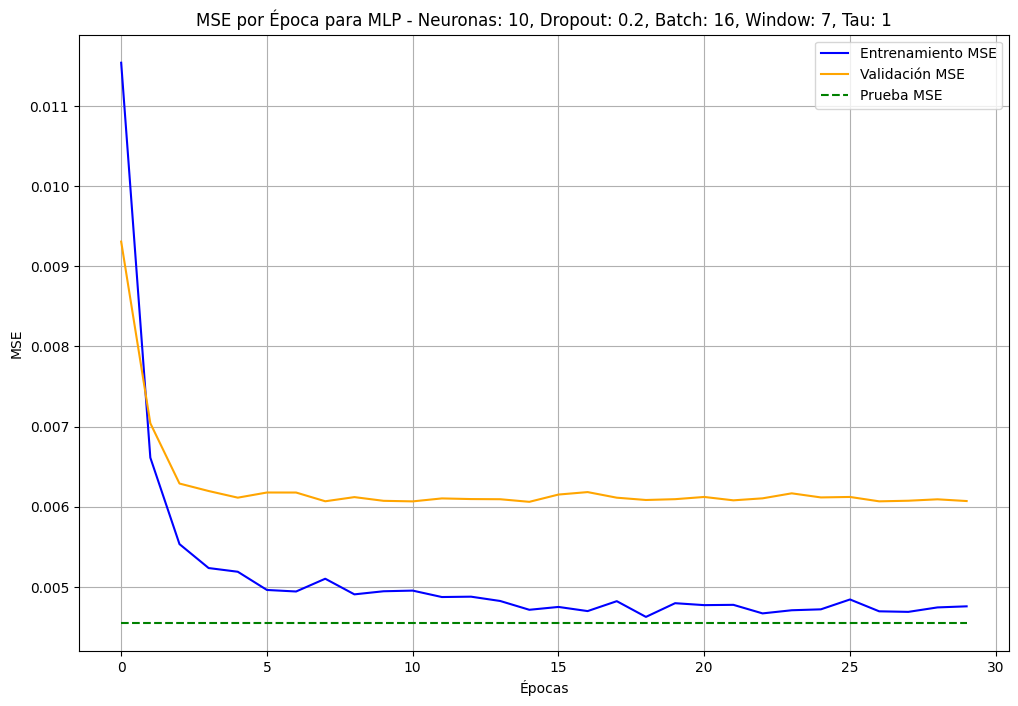

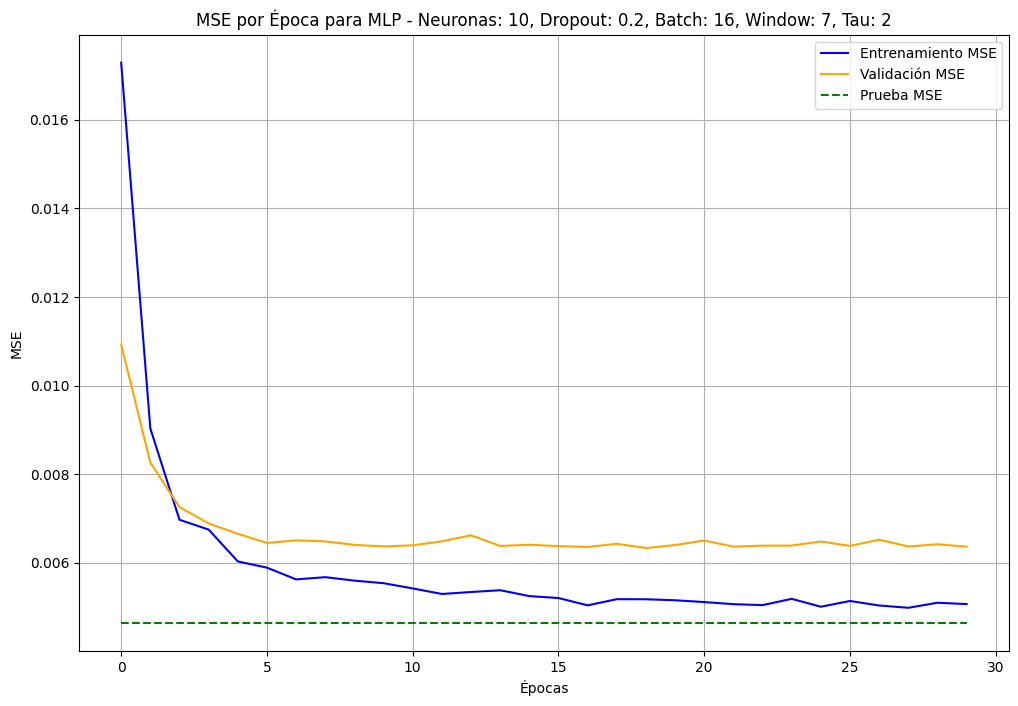

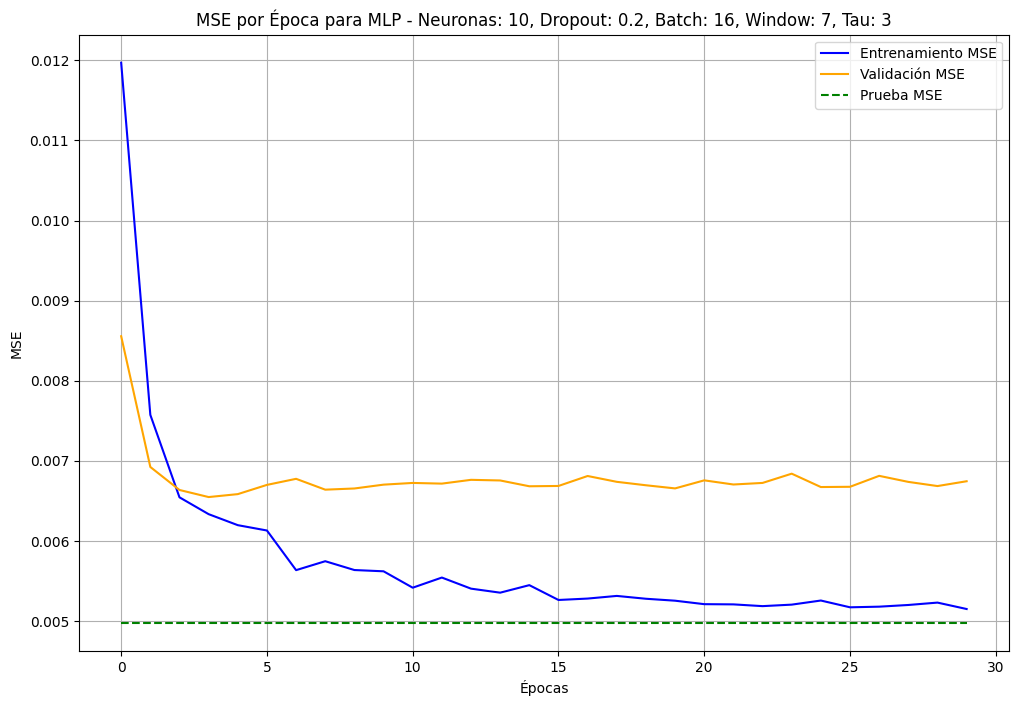

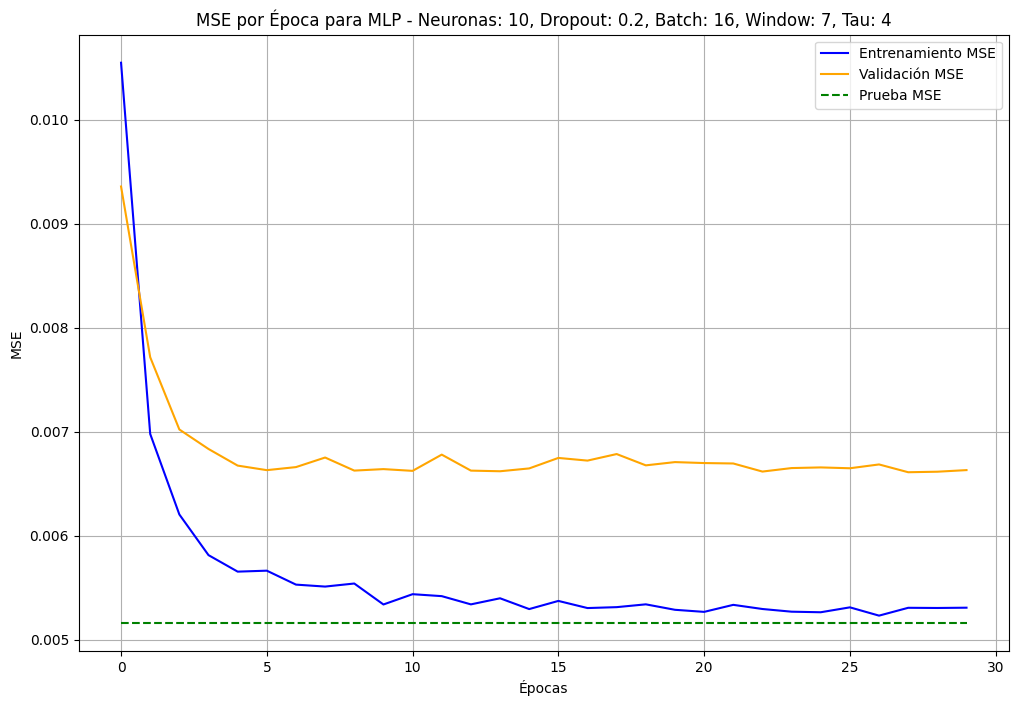

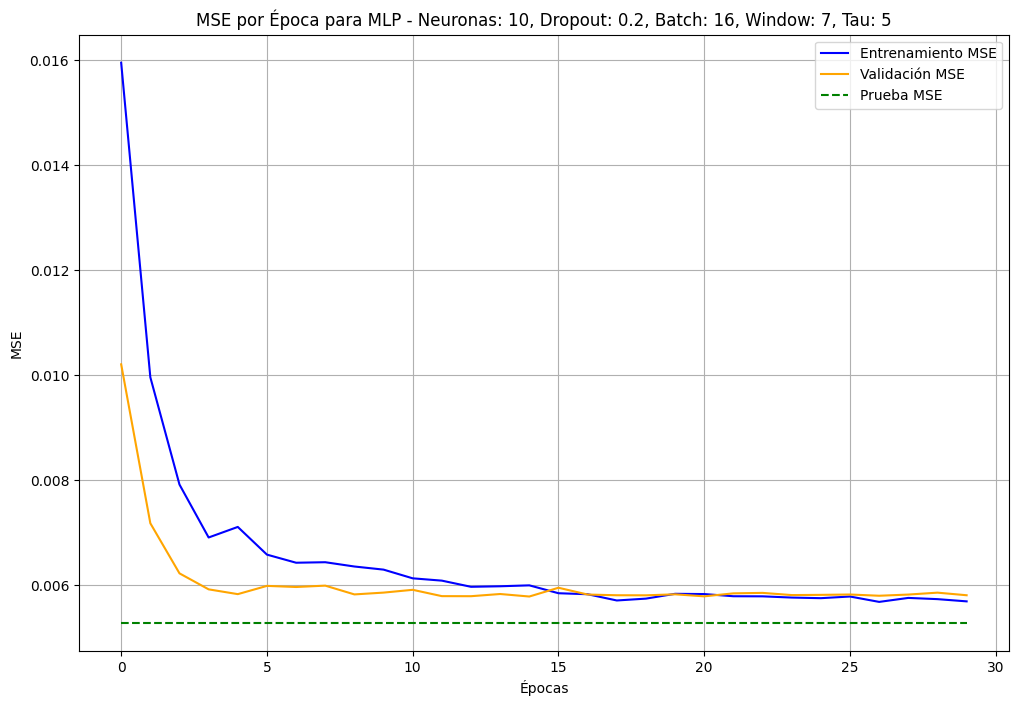

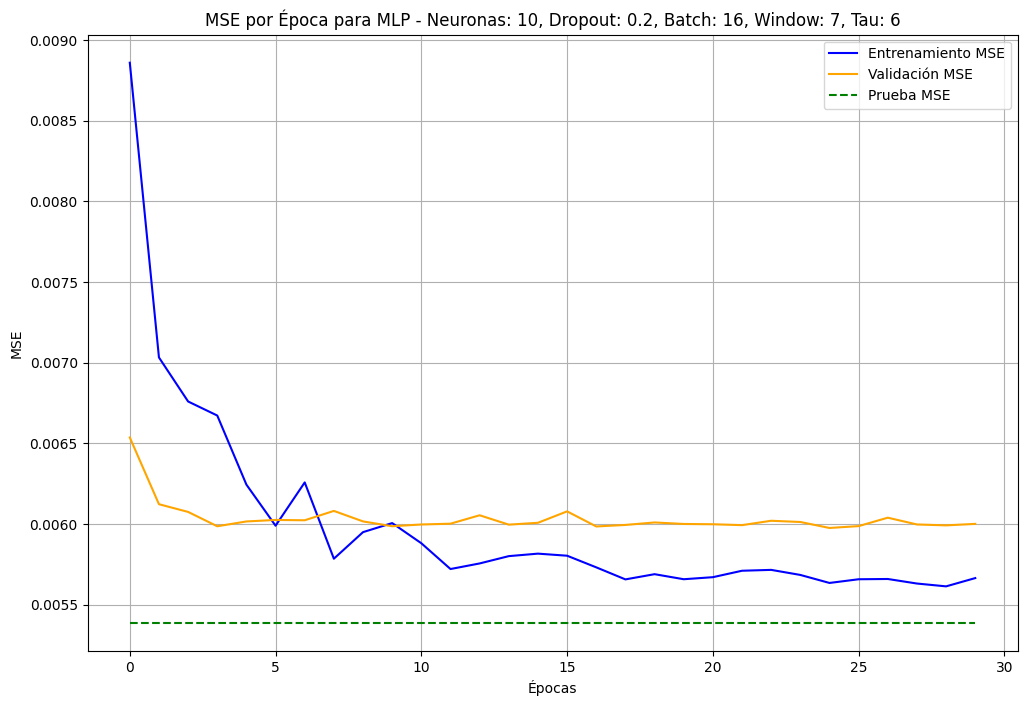

No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_1\MLP_10neurons_0.2dropout_batch16_window14_tau1_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_2\MLP_10neurons_0.2dropout_batch16_window14_tau2_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_3\MLP_10neurons_0.2dropout_batch16_window14_tau3_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_4\MLP_10neurons_0.2dropout_batch16_window14_tau4_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_5\MLP_10neurons_0.2dropout_batch16_window14_tau5_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_6\MLP_10neurons_0.2dropout_batch16_window14_tau6_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_7_tau_1\MLP_10neurons_0.2dropout_batch32_window7_tau1_history.j

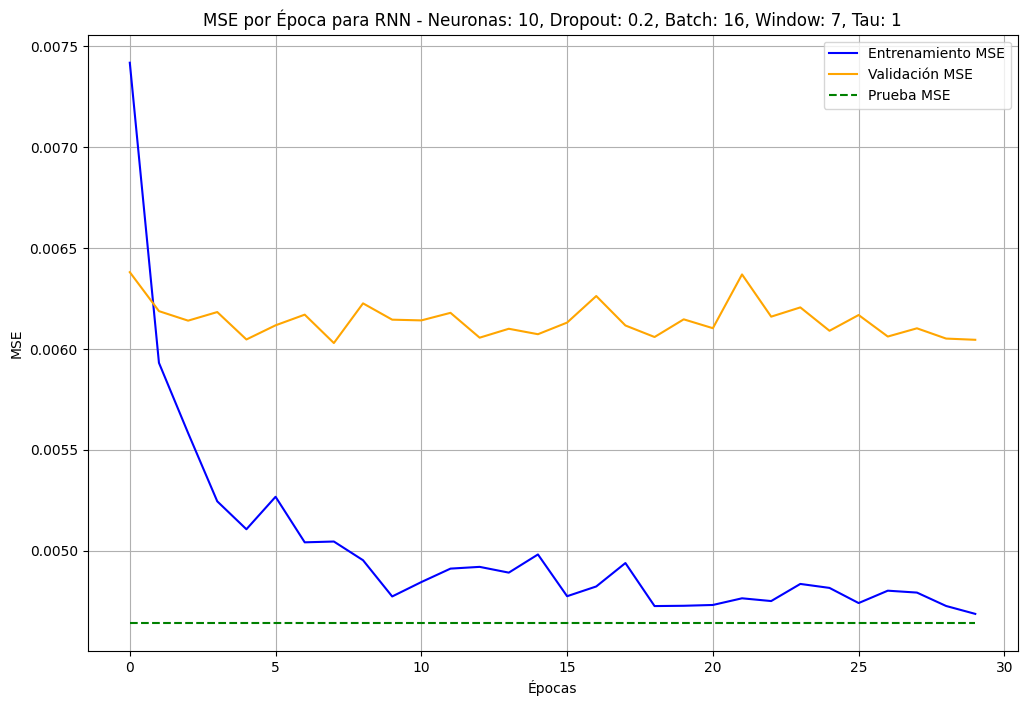

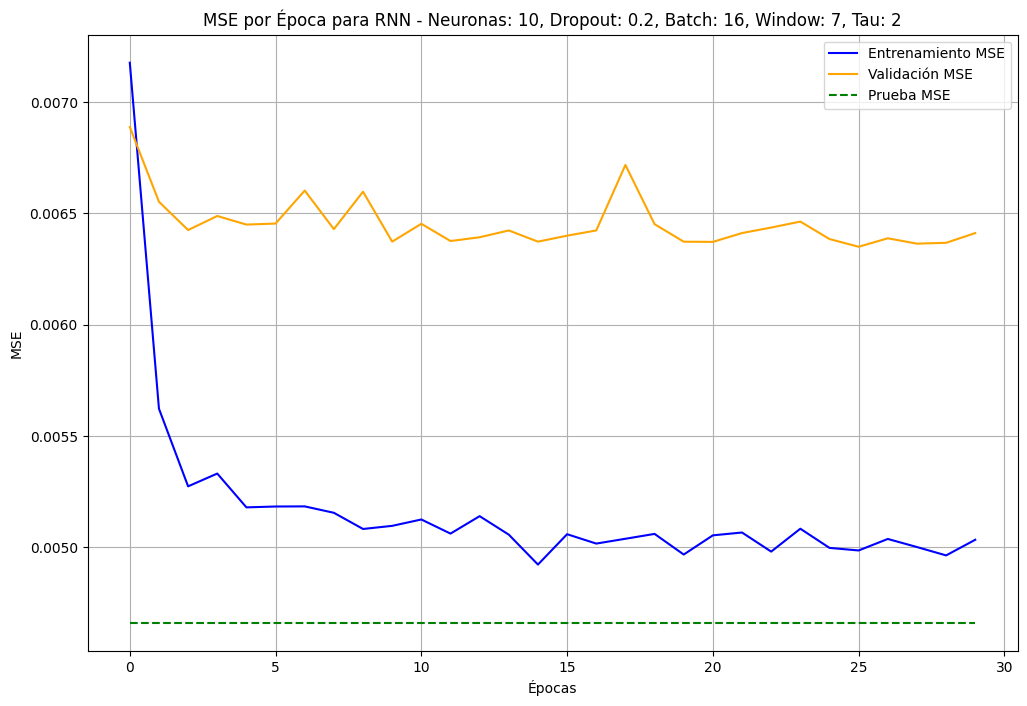

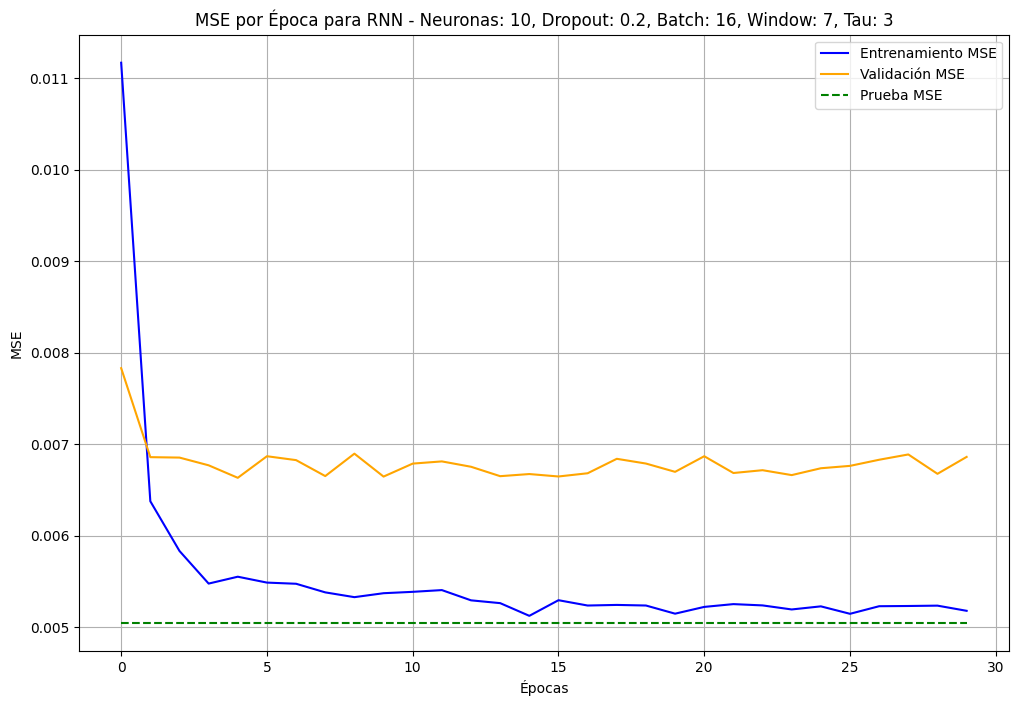

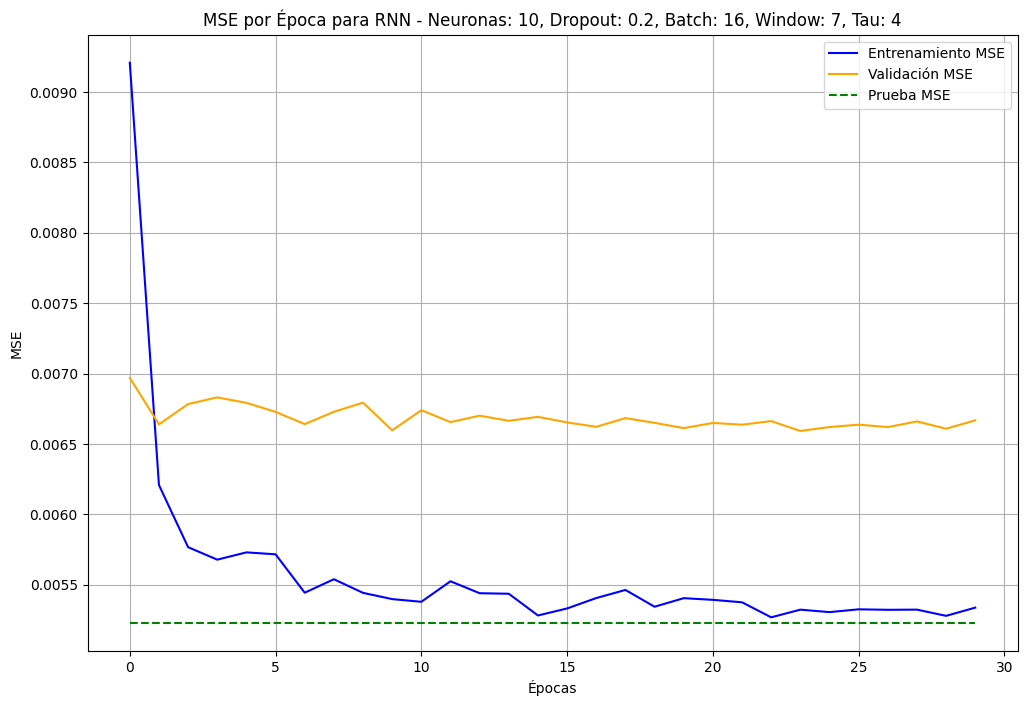

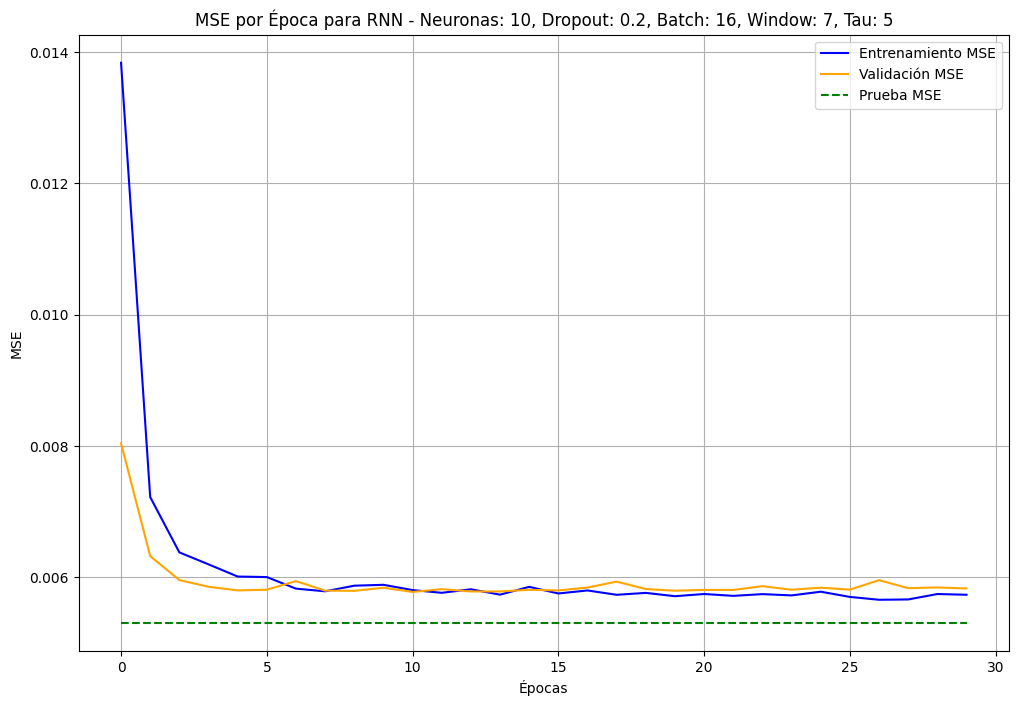

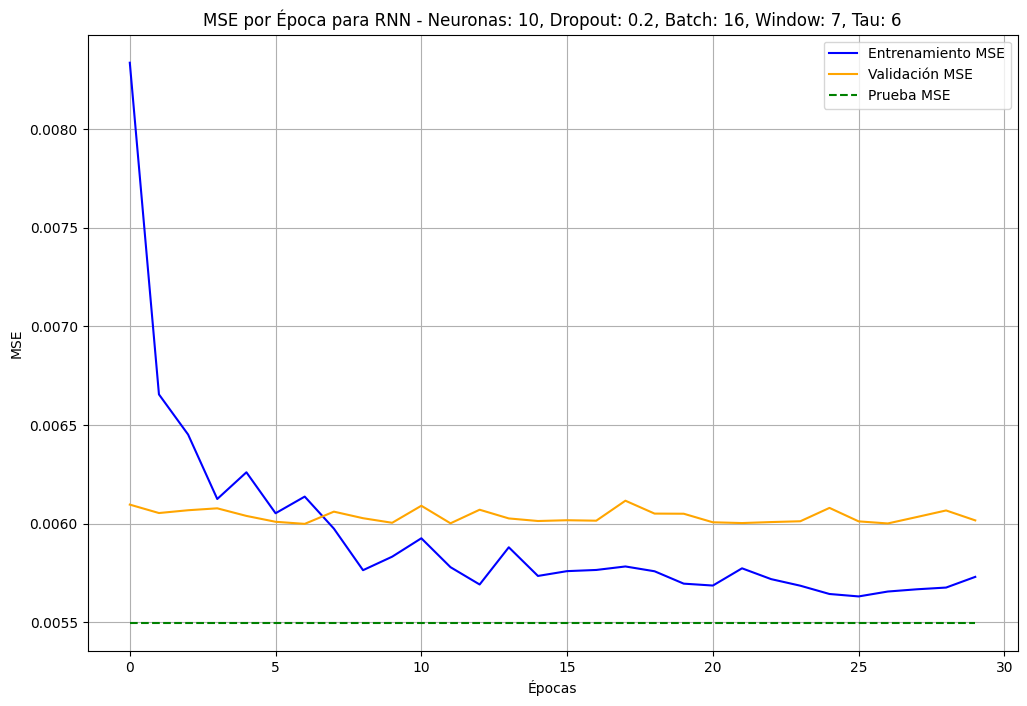

No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_1\RNN_10neurons_0.2dropout_batch16_window14_tau1_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_2\RNN_10neurons_0.2dropout_batch16_window14_tau2_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_3\RNN_10neurons_0.2dropout_batch16_window14_tau3_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_4\RNN_10neurons_0.2dropout_batch16_window14_tau4_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_5\RNN_10neurons_0.2dropout_batch16_window14_tau5_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_6\RNN_10neurons_0.2dropout_batch16_window14_tau6_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_7_tau_1\RNN_10neurons_0.2dropout_batch32_window7_tau1_history.j

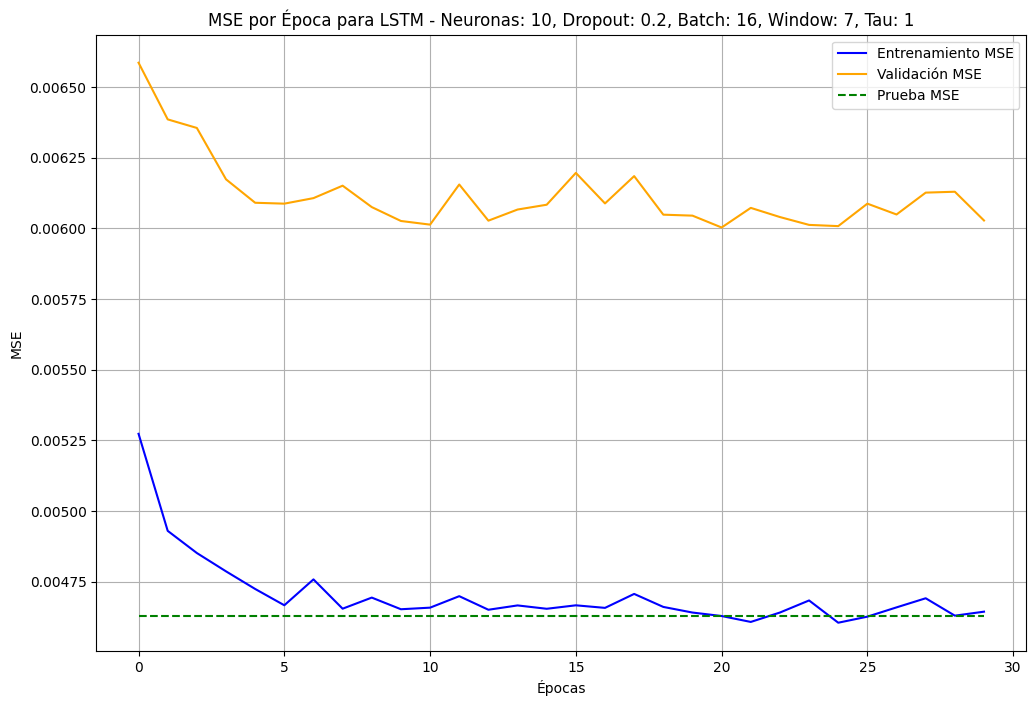

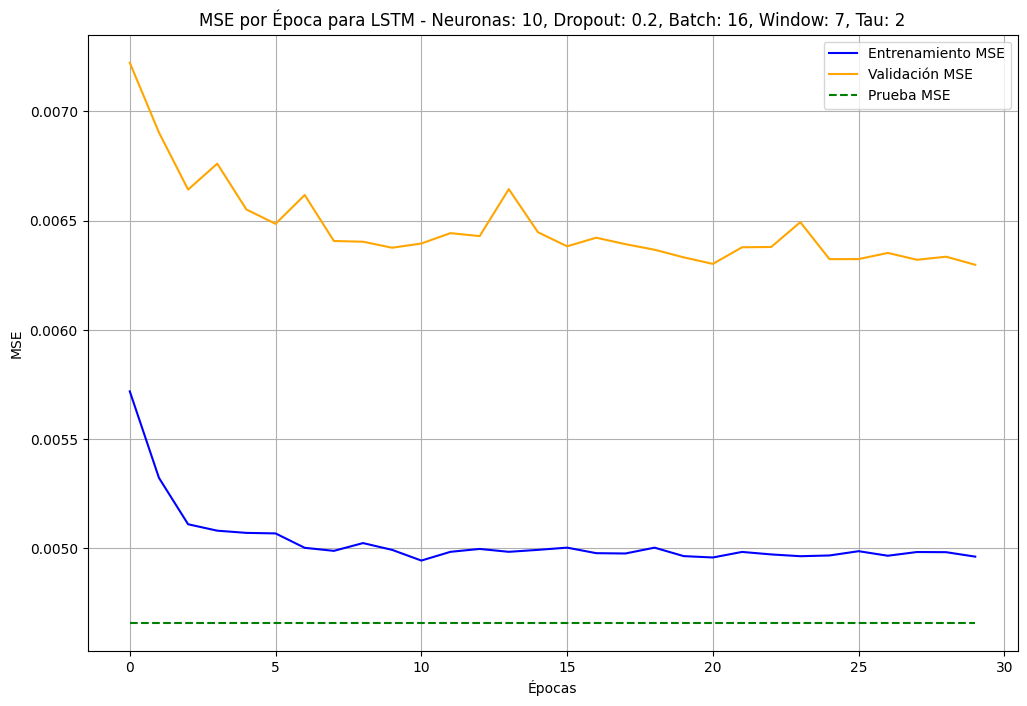

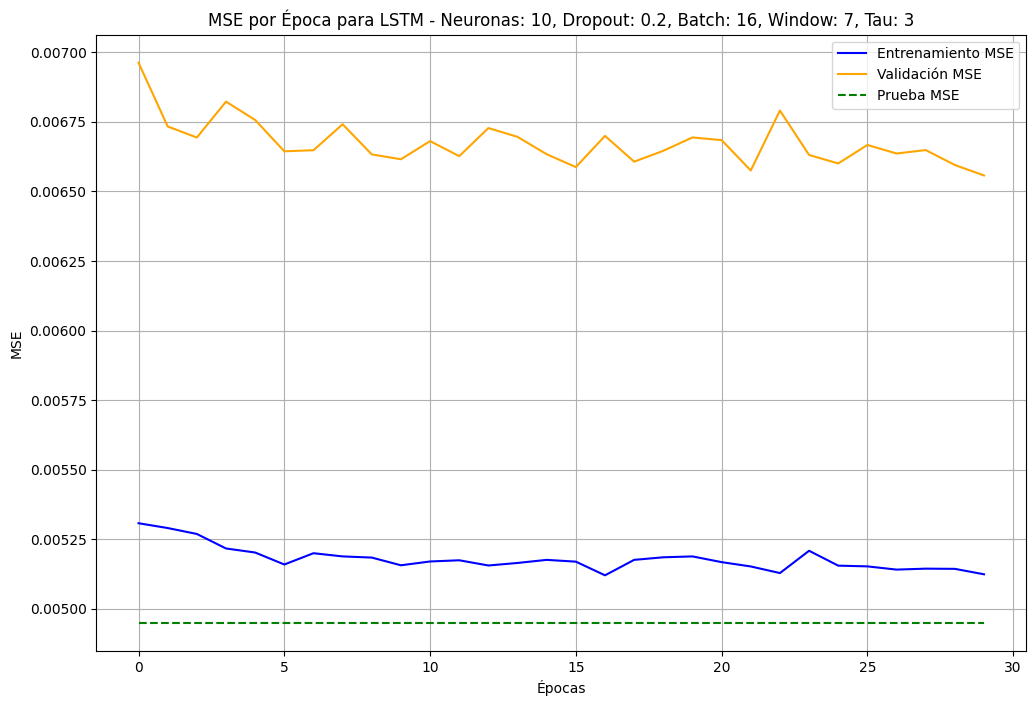

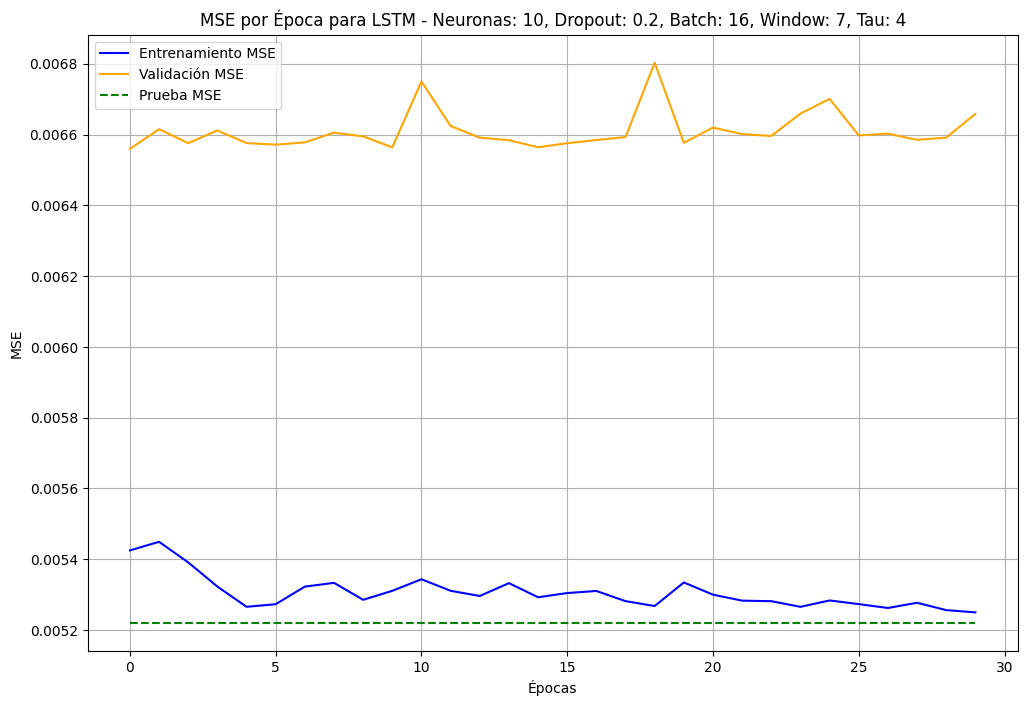

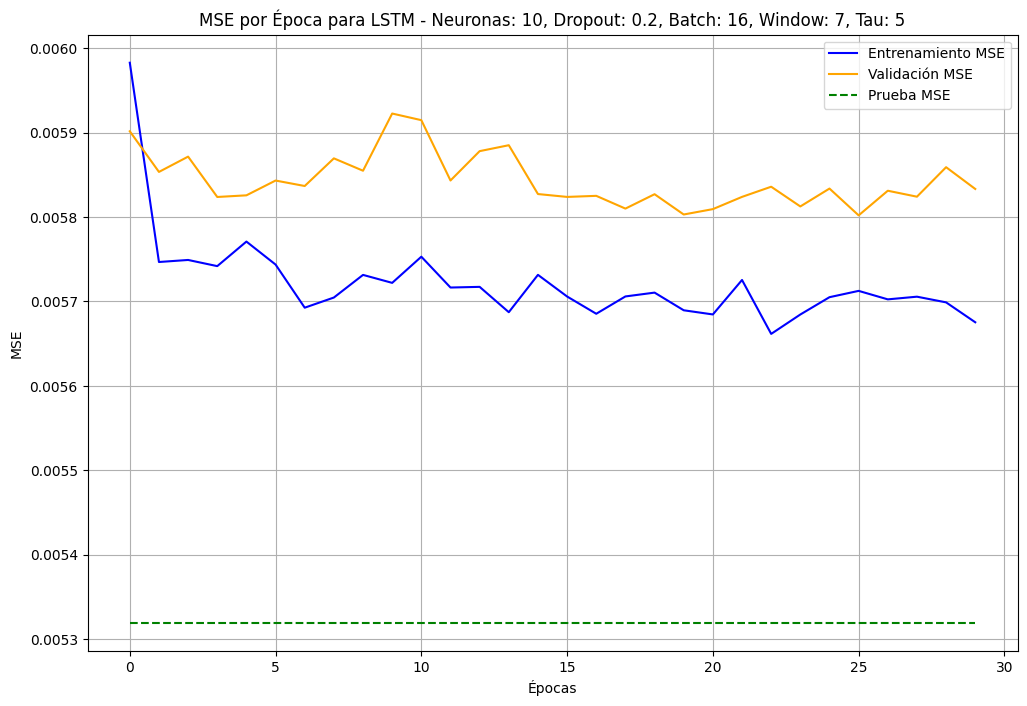

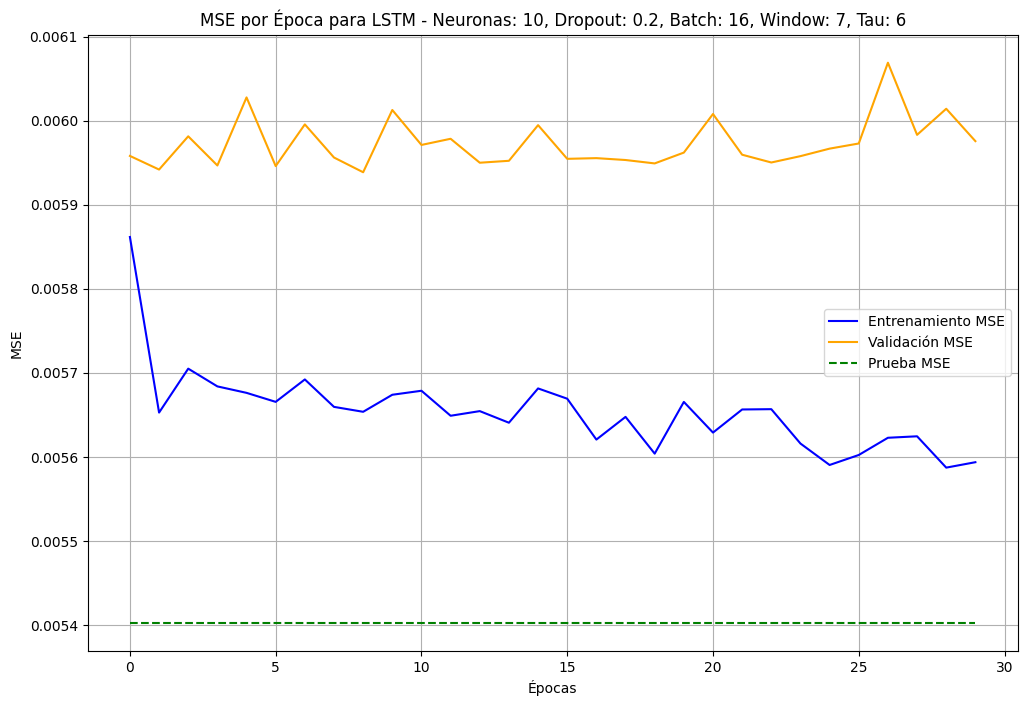

No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_1\LSTM_10neurons_0.2dropout_batch16_window14_tau1_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_2\LSTM_10neurons_0.2dropout_batch16_window14_tau2_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_3\LSTM_10neurons_0.2dropout_batch16_window14_tau3_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_4\LSTM_10neurons_0.2dropout_batch16_window14_tau4_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_5\LSTM_10neurons_0.2dropout_batch16_window14_tau5_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_14_tau_6\LSTM_10neurons_0.2dropout_batch16_window14_tau6_history.joblib
No se encontró el archivo de historial: modelos_volatility/models_window_7_tau_1\LSTM_10neurons_0.2dropout_batch32_window7_tau1_hi

In [ ]:
import matplotlib.pyplot as plt
from joblib import load
from itertools import product
import os

# Parámetros de especificaciones para generar combinaciones
model_names = ['MLP', 'RNN', 'LSTM']
neurons = [10, 100]
dropouts = [0.2, 0.4]
batch_sizes = [16, 32]
window_sizes = [7, 14]  # Asegúrate de incluir todos los tamaños de ventana que usaste
taus = range(1, 7)  # Rango de valores de tau

# Generar combinaciones de especificaciones
model_specs = [
    {'model_name': name, 'neurons': n, 'dropout': d, 'batch_size': b, 'window_size': w, 'tau': t}
    for name, n, d, b, w, t in product(model_names, neurons, dropouts, batch_sizes, window_sizes, taus)
]

# Función para cargar el historial
def load_history(filename):
    try:
        return load(filename)
    except FileNotFoundError:
        print(f"No se encontró el archivo de historial: {filename}")
        return None

# Función para graficar el historial con foco en el MSE
def plot_mse_history(history_data, spec):
    plt.figure(figsize=(12, 8))

    # Graficar MSE para entrenamiento, validación y prueba si están en el historial
    if 'mean_squared_error' in history_data:
        plt.plot(history_data['mean_squared_error'], label="Entrenamiento MSE", color='blue')
    if 'val_mean_squared_error' in history_data:
        plt.plot(history_data['val_mean_squared_error'], label="Validación MSE", color='orange')
    if 'test_mean_squared_error' in history_data:
        # `test_mean_squared_error` es un valor constante, así que se repetirá para cada época
        plt.plot([history_data['test_mean_squared_error'][0]] * len(history_data['mean_squared_error']), 
                 label="Prueba MSE", color='green', linestyle='--')

    # Configuración de título y etiquetas
    plt.title(f"MSE por Época para {spec['model_name']} - Neuronas: {spec['neurons']}, Dropout: {spec['dropout']}, Batch: {spec['batch_size']}, Window: {spec['window_size']}, Tau: {spec['tau']}")
    plt.xlabel("Épocas")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.show()

# Cargar y graficar el historial para cada modelo
for spec in model_specs:
    # Crear el nombre del archivo de historial con el nuevo formato de subcarpeta
    model_dir = f"modelos_volatility/models_window_{spec['window_size']}_tau_{spec['tau']}"
    base_filename = f"{spec['model_name']}_{spec['neurons']}neurons_{spec['dropout']}dropout_batch{spec['batch_size']}_window{spec['window_size']}_tau{spec['tau']}"
    history_filename = os.path.join(model_dir, f"{base_filename}_history.joblib")

    # Cargar el historial y graficar si existe
    history_data = load_history(history_filename)
    if history_data:
        plot_mse_history(history_data, spec)

En las primeras epocas de entrenamiento la variabilidad del error es alta, dado al proceso de parametrización natural de las redes neuronales sin embargo, a partir de la 5ta época se evidencia una estabilización de los errores, que parecen converger al error definitivo que tiene el modelo en el conjunto de test. Este ultimo es constante, dado a que no varía por las épocas porque los datos de test se prueban  al final del periodo de entrenamiento para calcular el rendimiento real del modelo. 

#### Item 9

C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\3863866602.py:45: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



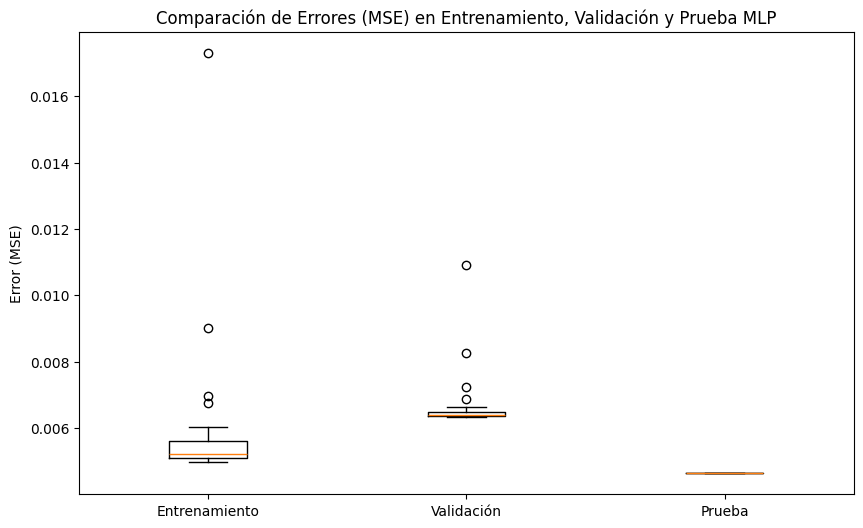

Estadístico de Kruskal-Wallis: 73.2088, Valor p: 0.0000
Las medianas de los errores son significativamente diferentes entre los conjuntos.


C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\3863866602.py:45: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



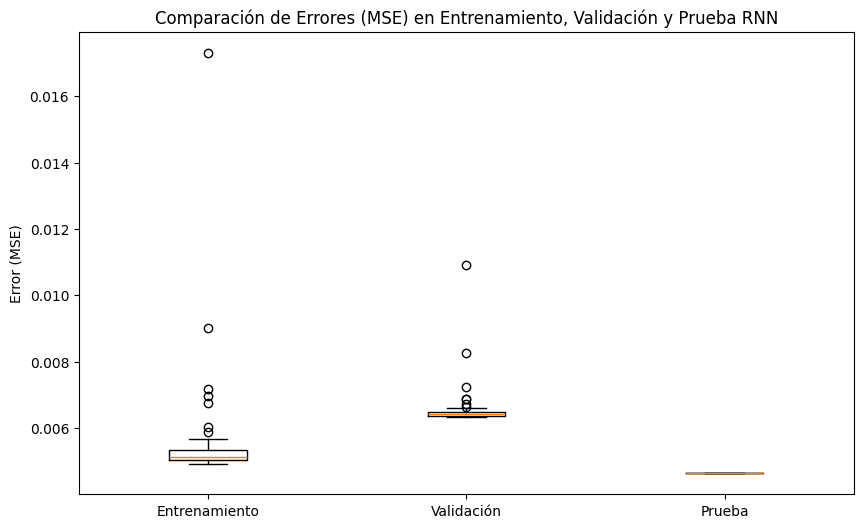

Estadístico de Kruskal-Wallis: 148.7812, Valor p: 0.0000
Las medianas de los errores son significativamente diferentes entre los conjuntos.


C:\Users\FBA\AppData\Local\Temp\ipykernel_21428\3863866602.py:45: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



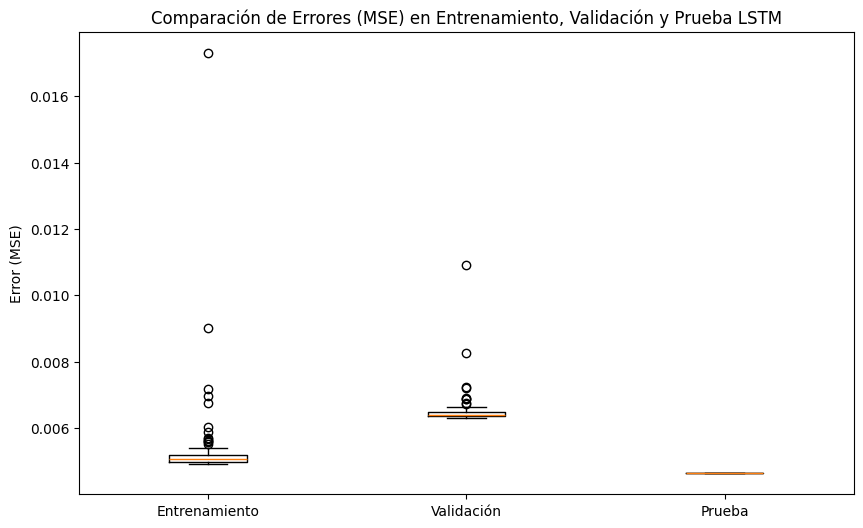

Estadístico de Kruskal-Wallis: 227.9524, Valor p: 0.0000
Las medianas de los errores son significativamente diferentes entre los conjuntos.


In [ ]:
import os
import matplotlib.pyplot as plt
from joblib import load
import numpy as np
import scipy.stats as stats

# Parámetros que coinciden con el nombre de archivo creado
model_names = ['MLP', 'RNN', 'LSTM']
neurons = [10, 100]
dropouts = [0.2, 0.4]
batch_sizes = [16, 32]
window_size = 7  # Ajustar según el análisis actual
tau = 2  # Ajustar según el análisis actual

# Diccionarios para almacenar los errores de cada conjunto
train_errors = []
val_errors = []
test_errors = []

# Cargar errores desde los archivos de historial
for model_name in model_names:
    for n in neurons:
        for d in dropouts:
            for b in batch_sizes:
                # Generar la ruta del archivo de historial
                model_dir = f'modelos_volatility/models_window_{window_size}_tau_{tau}'
                base_filename = f"{model_name}_{n}neurons_{d}dropout_batch{b}_window{window_size}_tau{tau}_history.joblib"
                history_path = os.path.join(model_dir, base_filename)
                
                # Cargar el historial si existe
                if os.path.exists(history_path):
                    history_data = load(history_path)
                    
                    # Extraer errores (MSE) de entrenamiento, validación y prueba si están disponibles
                    if 'mean_squared_error' in history_data:
                        train_errors.extend(history_data['mean_squared_error'])
                    if 'val_mean_squared_error' in history_data:
                        val_errors.extend(history_data['val_mean_squared_error'])
                    if 'test_mean_squared_error' in history_data:
                        # Error de prueba es constante, se extiende en el tamaño de épocas para la comparación
                        test_errors.extend([history_data['test_mean_squared_error'][0]] * len(history_data['mean_squared_error']))

    # Generar los boxplots
    plt.figure(figsize=(10, 6))
    plt.boxplot([train_errors, val_errors, test_errors], labels=['Entrenamiento', 'Validación', 'Prueba'])
    plt.title(f"Comparación de Errores (MSE) en Entrenamiento, Validación y Prueba {model_name}")
    plt.ylabel("Error (MSE)")
    plt.show()

    # Realizar la prueba de Kruskal-Wallis para comparar las medianas de los errores
    stat, p_value = stats.kruskal(train_errors, val_errors, test_errors)
    print(f"Estadístico de Kruskal-Wallis: {stat:.4f}, Valor p: {p_value:.4f}")

    # Interpretación de resultados
    if p_value < 0.05:
        print("Las medianas de los errores son significativamente diferentes entre los conjuntos.")
    else:
        print("No hay diferencias significativas en las medianas de los errores entre los conjuntos.")


Tiene sentido que las medianas de los errores en entrenamiento validación y test sean siginfiicativamente diferente, dado a que en las primeras épocas de entrenamiento el modelo en entrenamiento tiene mayor variabilidad, la cual se estabiliza en el proceso de validación dando como resultado un error esperado definitivo en el conjunto de prueba. 

#### Item 10. Desplegar serie original.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def desplegar_predicciones_y_datos_originales(predictions_multivariate_discharge_scaled, 
                                              original_series, 
                                              window_size_train, window_size_val, window_size_test, 
                                              num_ventanas, original_length, 
                                              modelo='MLP', zoom_range=None,
                                              trainY_matrices=None, valY_matrices=None, testY_matrices=None):

    # Inicializar la serie reconstruida con valores NaN
    reconstructed_predictions = np.full(original_length, np.nan)

    # Desplegar las predicciones en su posición correcta
    for tau in range(1, num_ventanas + 1):
        train_pred = predictions_multivariate_discharge_scaled[modelo][window_size_train/2][f'Train_Pred_tau_{tau}']
        val_pred = predictions_multivariate_discharge_scaled[modelo][window_size_val][f'Val_Pred_tau_{tau}']
        test_pred = predictions_multivariate_discharge_scaled[modelo][window_size_test][f'Test_Pred_tau_{tau}']
        
        for i in range(len(train_pred) // window_size_train):
            train_start = i * (window_size_train + window_size_val + window_size_test)
            val_start = train_start + window_size_train
            test_start = val_start + window_size_val

            reconstructed_predictions[train_start:train_start + window_size_train] = train_pred[i * window_size_train:(i + 1) * window_size_train]
            reconstructed_predictions[val_start:val_start + window_size_val] = val_pred[i * window_size_val:(i + 1) * window_size_val]
            reconstructed_predictions[test_start:test_start + window_size_test] = test_pred[i * window_size_test:(i + 1) * window_size_test]

    reconstructed_predictions = pd.Series(reconstructed_predictions, index=original_series.index)

    # Crear las secciones de entrenamiento, validación y prueba para los datos originales
    original_train_series = np.full(original_length, np.nan)
    original_val_series = np.full(original_length, np.nan)
    original_test_series = np.full(original_length, np.nan)

    # Insertar valores de los datos originales en las posiciones correspondientes
    for tau in range(1, num_ventanas + 1):
        for i in range(len(trainY_matrices[window_size_train/2][tau]) // window_size_train):
            train_start = i * (window_size_train + window_size_val + window_size_test)
            val_start = train_start + window_size_train
            test_start = val_start + window_size_val

            original_train_series[train_start:train_start + window_size_train] = trainY_matrices[window_size_train/2][tau][i * window_size_train:(i + 1) * window_size_train]
            original_val_series[val_start:val_start + window_size_val] = valY_matrices[window_size_val][tau][i * window_size_val:(i + 1) * window_size_val]
            original_test_series[test_start:test_start + window_size_test] = testY_matrices[window_size_test][tau][i * window_size_test:(i + 1) * window_size_test]

    # Convertir a Series de Pandas para facilitar la visualización
    original_train_series = pd.Series(original_train_series, index=original_series.index)
    original_val_series = pd.Series(original_val_series, index=original_series.index)
    original_test_series = pd.Series(original_test_series, index=original_series.index)

    # Gráfico completo con predicciones y datos originales
    plt.figure(figsize=(14, 8))
    plt.plot(original_series, label='Serie Original', color='black')
    plt.plot(reconstructed_predictions, label=f'Predicciones Restauradas - Modelo {modelo}', linestyle='--', color='blue')
    plt.plot(original_train_series, label='Datos Originales - Entrenamiento', color='cyan')
    plt.plot(original_val_series, label='Datos Originales - Validación', color='orange')
    plt.plot(original_test_series, label='Datos Originales - Prueba', color='green')
    
    plt.title(f"Serie Completa - Modelo {modelo} con Datos Originales")
    plt.xlabel("Índice de Tiempo")
    plt.ylabel("Valor de Predicción")
    plt.legend()
    plt.show()

    # Gráfico de zoom en el rango especificado
    if zoom_range is not None:
        zoom_start, zoom_end = zoom_range
        plt.figure(figsize=(14, 8))
        plt.plot(original_series[zoom_start:zoom_end], label='Serie Original (Zoom)', linestyle='--', color='grey')
        plt.plot(reconstructed_predictions[zoom_start:zoom_end], label=f'Predicciones Restauradas - Modelo {modelo} (Zoom)', linestyle='--', color='blue')
        plt.plot(original_train_series[zoom_start:zoom_end], label='Datos Originales - Entrenamiento (Zoom)', color='cyan')
        plt.plot(original_val_series[zoom_start:zoom_end], label='Datos Originales - Validación (Zoom)', color='orange')
        plt.plot(original_test_series[zoom_start:zoom_end], label='Datos Originales - Prueba (Zoom)', color='green')

        plt.title(f"Zoom en el Rango [{zoom_start}:{zoom_end}] - Modelo {modelo} con Datos Originales")
        plt.xlabel("Índice de Tiempo")
        plt.ylabel("Valor de Predicción")
        plt.legend()
        plt.show()

    return reconstructed_predictions




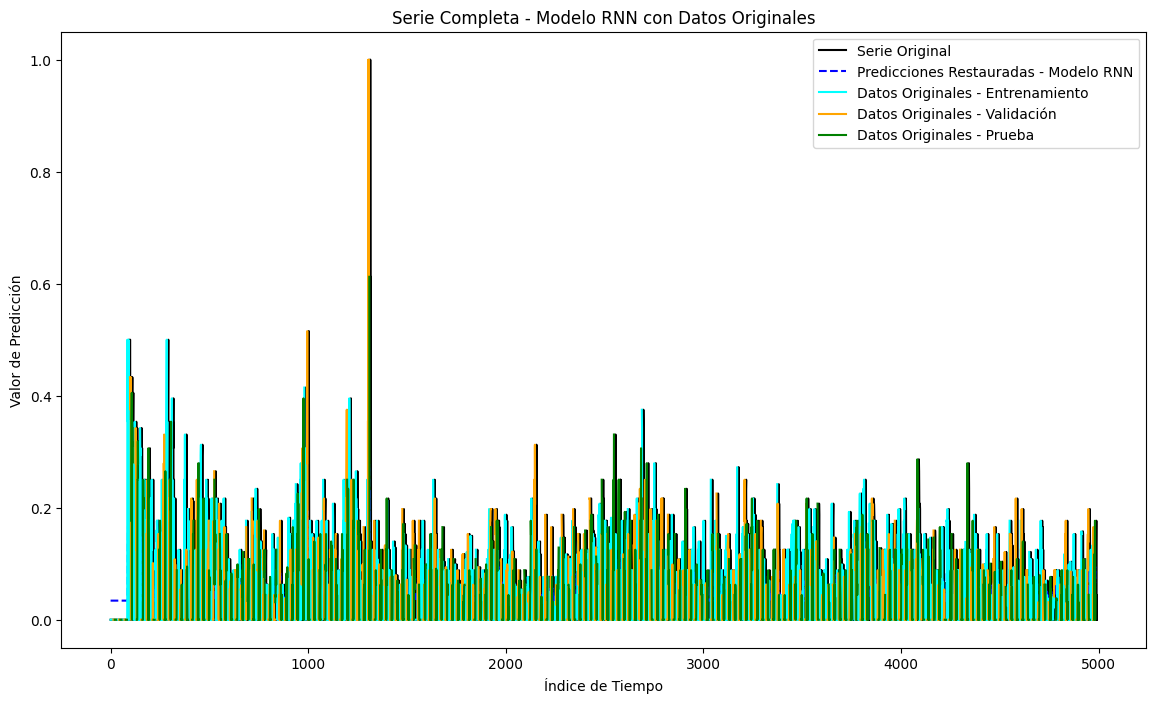

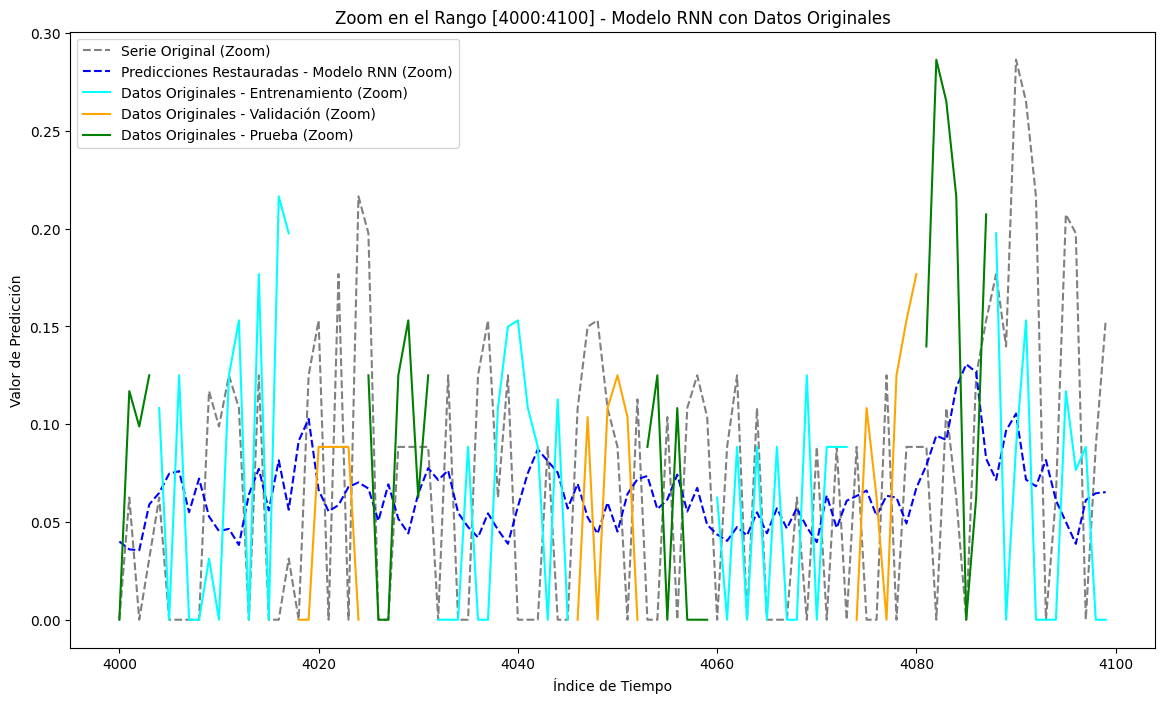

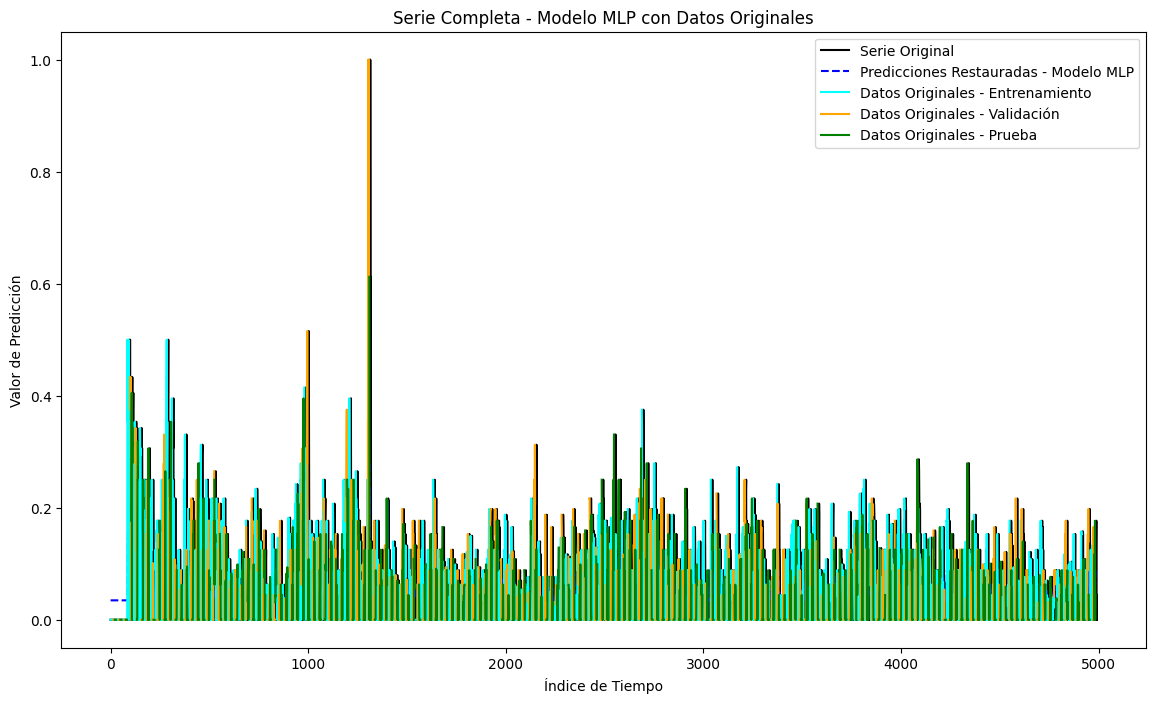

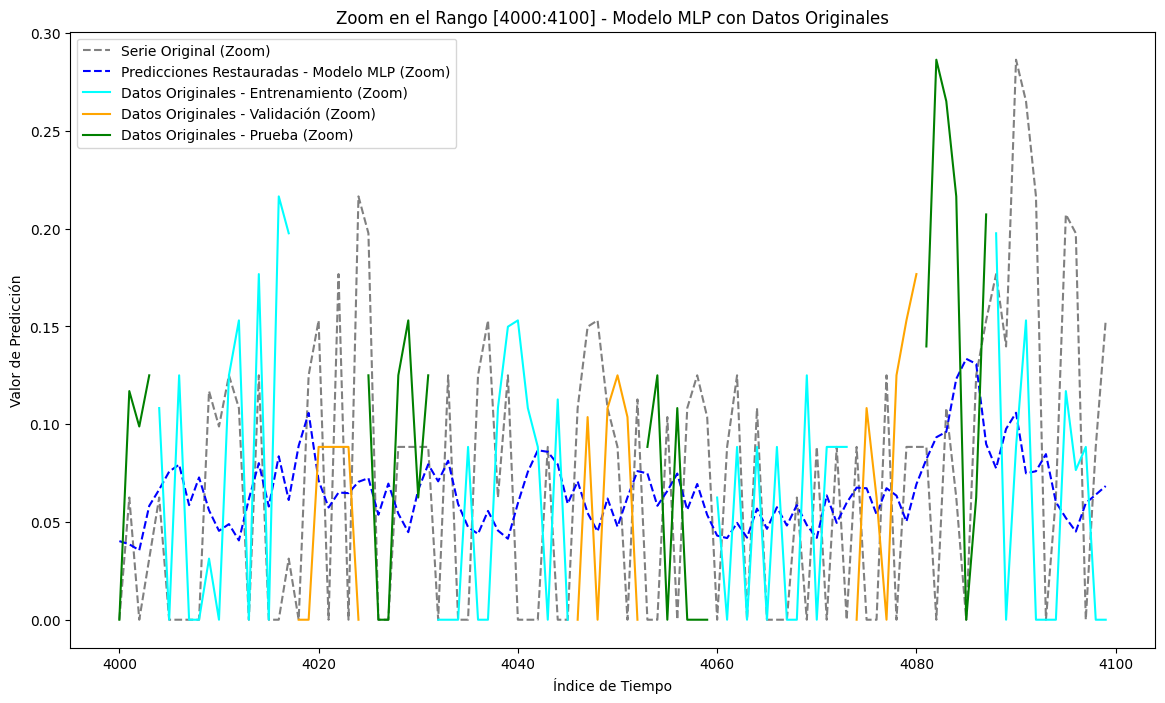

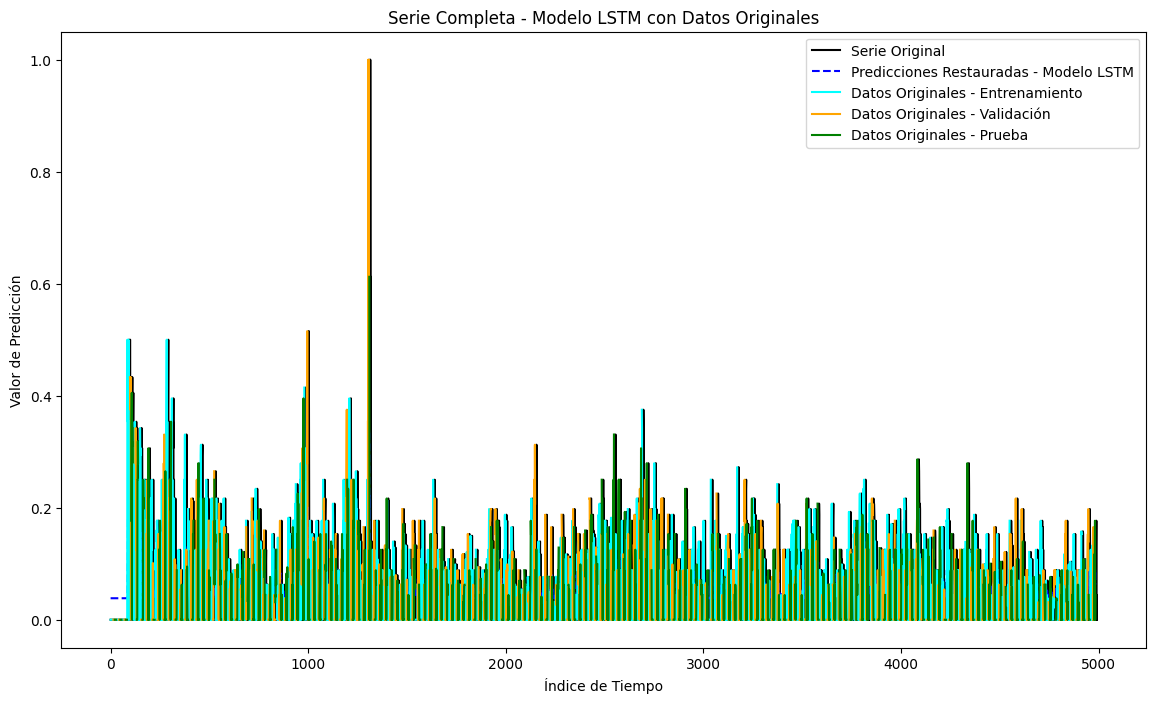

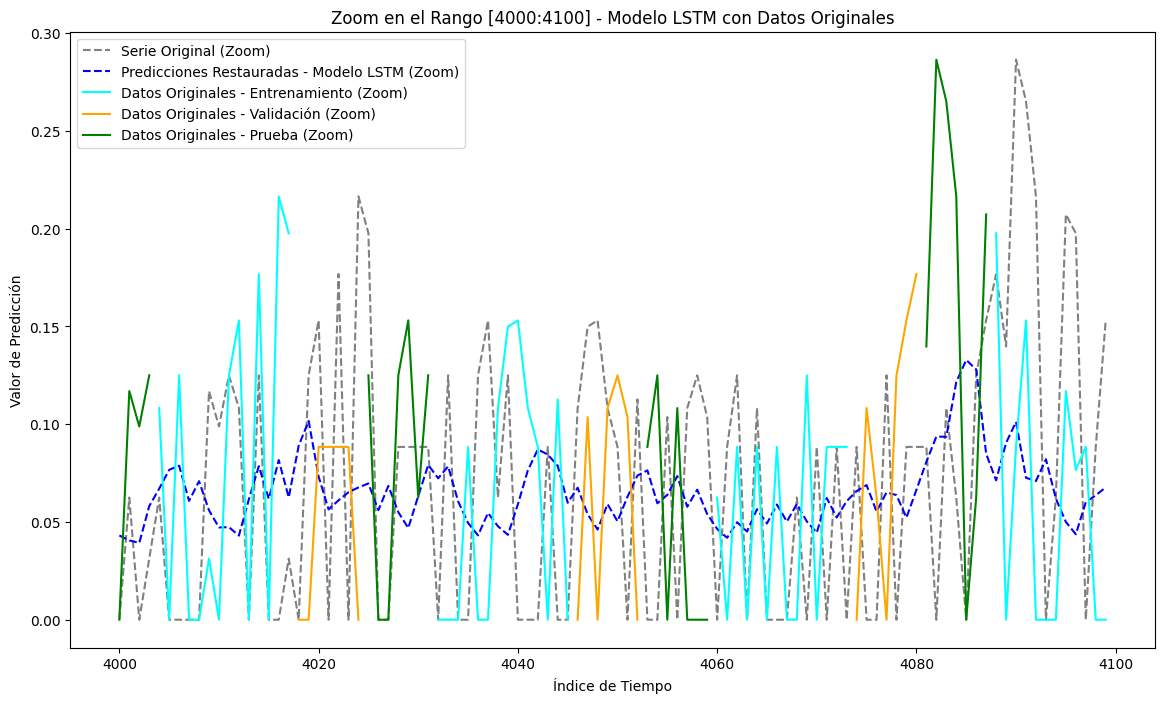

In [ ]:
reconstructed_predictions = desplegar_predicciones_y_datos_originales(predictions_multivariate_discharge_scaled, 
                                                                  original_series=df_volatility_scaled, 
                                                                  window_size_train=14, 
                                                                  window_size_val=7, 
                                                                  window_size_test=7, 
                                                                  num_ventanas=2, 
                                                                  original_length=4992,
                                                                  modelo='RNN',
                                                                  zoom_range=(4000, 4100),trainY_matrices=trainY_matrices,valY_matrices=valY_matrices,testY_matrices=testY_matrices)  # Definir el rango de zoom aquí


reconstructed_predictions = desplegar_predicciones_y_datos_originales(predictions_multivariate_discharge_scaled, 
                                                                  original_series=df_volatility_scaled, 
                                                                  window_size_train=14, 
                                                                  window_size_val=7, 
                                                                  window_size_test=7, 
                                                                  num_ventanas=2, 
                                                                  original_length=4992,
                                                                  modelo='MLP',
                                                                  zoom_range=(4000 , 4100),trainY_matrices=trainY_matrices,valY_matrices=valY_matrices,testY_matrices=testY_matrices)  # Definir el rango de zoom aquí


reconstructed_predictions = desplegar_predicciones_y_datos_originales(predictions_multivariate_discharge_scaled, 
                                                                  original_series=df_volatility_scaled, 
                                                                  window_size_train=14, 
                                                                  window_size_val=7, 
                                                                  window_size_test=7, 
                                                                  num_ventanas=2, 
                                                                  original_length=4992,
                                                                  modelo='LSTM',
                                                                  zoom_range=(4000 , 4100),trainY_matrices=trainY_matrices,valY_matrices=valY_matrices,testY_matrices=testY_matrices)  # Definir el rango de zoom aquí



In [546]:
# Extraer valores de la columna 'discharge_armley'
values = data_us['discharge_armley'].values.reshape(-1, 1)  # Asegúrate de que los valores sean 2D

# Definir proporciones para dividir los datos
train_size = int(len(values) * 0.7)
val_size = int(len(values) * 0.15)

# Separar los datos
train_data = values[:train_size]
val_data = values[train_size:train_size + val_size]
test_data = values[train_size + val_size:]

print(f"Train data length: {len(train_data)}")
print(f"Validation data length: {len(val_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 884
Validation data length: 189
Test data length: 191


In [547]:
def get_XY(data, time_steps):
    X, Y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        Y.append(data[i + time_steps])
    return np.array(X), np.array(Y)

# Definir el número de pasos de tiempo
time_steps = 32

# Crear ventanas deslizantes para cada conjunto
trainX, trainY = get_XY(train_data, time_steps)
valX, valY = get_XY(val_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

# Ajustar la forma para el modelo ESN
trainX = trainX.reshape((trainX.shape[0], trainX.shape[1], 1))
valX = valX.reshape((valX.shape[0], valX.shape[1], 1))
testX = testX.reshape((testX.shape[0], testX.shape[1], 1))

trainY = trainY.reshape(-1, 1)
valY = valY.reshape(-1, 1)
testY = testY.reshape(-1, 1)

# Verificar las formas
print(f"trainX shape: {trainX.shape}, trainY shape: {trainY.shape}")
print(f"valX shape: {valX.shape}, valY shape: {valY.shape}")
print(f"testX shape: {testX.shape}, testY shape: {testY.shape}")



trainX shape: (852, 32, 1), trainY shape: (852, 1)
valX shape: (157, 32, 1), valY shape: (157, 1)
testX shape: (159, 32, 1), testY shape: (159, 1)


In [548]:
# Definir los rangos de parámetros a explorar
reservoir_units_list = [100, 200, 500]
prior_stddev_list = [0.1, 0.25, 0.5]
alpha_list = [0.01, 0.1, 0.5]
beta_list = [0.01, 0.1, 0.5]

# Variables para guardar el mejor modelo y el mejor error
best_mse = float('inf')
best_params = None
best_model = None

# Ciclo para iterar sobre todos los parámetros
for reservoir_units in reservoir_units_list:
    for prior_stddev in prior_stddev_list:
        for alpha in alpha_list:
            for beta in beta_list:
                # Crear el modelo BESN con los parámetros actuales
                model_ESN = create_bayesian_ESN(
                    input_shape=(trainX.shape[1], trainX.shape[2]),
                    reservoir_units=reservoir_units,
                    output_dim=1,
                    prior_stddev=prior_stddev,
                    alpha=alpha,
                    beta=beta
                )
                 # Crear dataset con drop_remainder=True
                train_dataset = Dataset.from_tensor_slices((trainX, trainY)).batch(32, drop_remainder=True)
                val_dataset = Dataset.from_tensor_slices((valX, valY)).batch(32, drop_remainder=True)

                # Entrenar el modelo
                model_ESN.fit(train_dataset, epochs=20, validation_data=val_dataset, verbose=0)

                # Realizar predicciones en el conjunto de validación
                val_predict = model_ESN.predict(valX)

                # Calcular el MSE en el conjunto de validación
                mse = mean_squared_error(valY, val_predict)

                # Verificar si es el mejor modelo hasta ahora
                if mse < best_mse:
                    best_mse = mse
                    best_params = (reservoir_units, prior_stddev, alpha, beta)
                    best_model = model_ESN

                print(f"Reservoir Units: {reservoir_units}, Prior Stddev: {prior_stddev}, Alpha: {alpha}, Beta: {beta} => Validation MSE: {mse:.4f}")

# Mostrar los mejores parámetros
print(f"Mejor modelo con MSE: {best_mse:.4f}")
print(f"Reservoir Units: {best_params[0]}, Prior Stddev: {best_params[1]}, Alpha: {best_params[2]}, Beta: {best_params[3]}")


5/5 [==============================] - 0s 2ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.01, Beta: 0.01 => Validation MSE: 264.6302
5/5 [==============================] - 0s 1ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.01, Beta: 0.1 => Validation MSE: 204.8209
5/5 [==============================] - 0s 2ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.01, Beta: 0.5 => Validation MSE: 171.9109
5/5 [==============================] - 0s 2ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.1, Beta: 0.01 => Validation MSE: 276.5406
5/5 [==============================] - 0s 3ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.1, Beta: 0.1 => Validation MSE: 264.5349
5/5 [==============================] - 0s 3ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.1, Beta: 0.5 => Validation MSE: 224.2974
5/5 [==============================] - 0s 2ms/step
Reservoir Units: 100, Prior Stddev: 0.1, Alpha: 0.5, Beta: 0.01 => Validation MSE: 277.5596


In [549]:
# Crear el modelo BESN con la mejor resultado de parámetros Reservoir Units: 200, Prior Stddev: 0.5, Alpha: 0.01, Beta: 0.5
model_ESN = create_bayesian_ESN(
    input_shape=(trainX.shape[1], trainX.shape[2]),  # Dimensión de las secuencias de entrada
    reservoir_units=200,  # Puedes ajustar este valor según sea necesario
    output_dim=1,         # Solo estás prediciendo un valor por secuencia
    prior_stddev=0.5,     # Desviación estándar para la regularización bayesiana
    alpha=0.01,            # Parámetro de regularización
    beta=0.5              # Parámetro de regularización
)


In [561]:
from tensorflow.data import Dataset
# Crear dataset con drop_remainder=True
train_dataset = Dataset.from_tensor_slices((trainX, trainY)).batch(30, drop_remainder=False)
val_dataset = Dataset.from_tensor_slices((valX, valY)).batch(30, drop_remainder=False)
# Entrenar usando el dataset
model_ESN.fit(train_dataset, epochs=50)


Epoch 1/50


29/29 [==============================] - 0s 3ms/step - loss: 458.2215
Epoch 2/50
29/29 [==============================] - 0s 2ms/step - loss: 282.4636
Epoch 3/50
29/29 [==============================] - 0s 2ms/step - loss: 364.9670
Epoch 4/50
29/29 [==============================] - 0s 3ms/step - loss: 368.4605
Epoch 5/50
29/29 [==============================] - 0s 3ms/step - loss: 431.2269
Epoch 6/50
29/29 [==============================] - 0s 3ms/step - loss: 277.6337
Epoch 7/50
29/29 [==============================] - 0s 2ms/step - loss: 297.8205
Epoch 8/50
29/29 [==============================] - 0s 3ms/step - loss: 328.5532
Epoch 9/50
29/29 [==============================] - 0s 3ms/step - loss: 442.7350
Epoch 10/50
29/29 [==============================] - 0s 3ms/step - loss: 352.4583
Epoch 11/50
29/29 [==============================] - 0s 3ms/step - loss: 415.0216
Epoch 12/50
29/29 [==============================] - 0s 3ms/step - loss: 291.6123
Epoch 13/50
29/29 [=================

In [562]:
train_predict_ESN = model_ESN.predict(trainX)
test_predict_ESN = model_ESN.predict(testX)
val_predict_ESN = model_ESN.predict(valX)

5/5 [==============================] - 0s 2ms/step


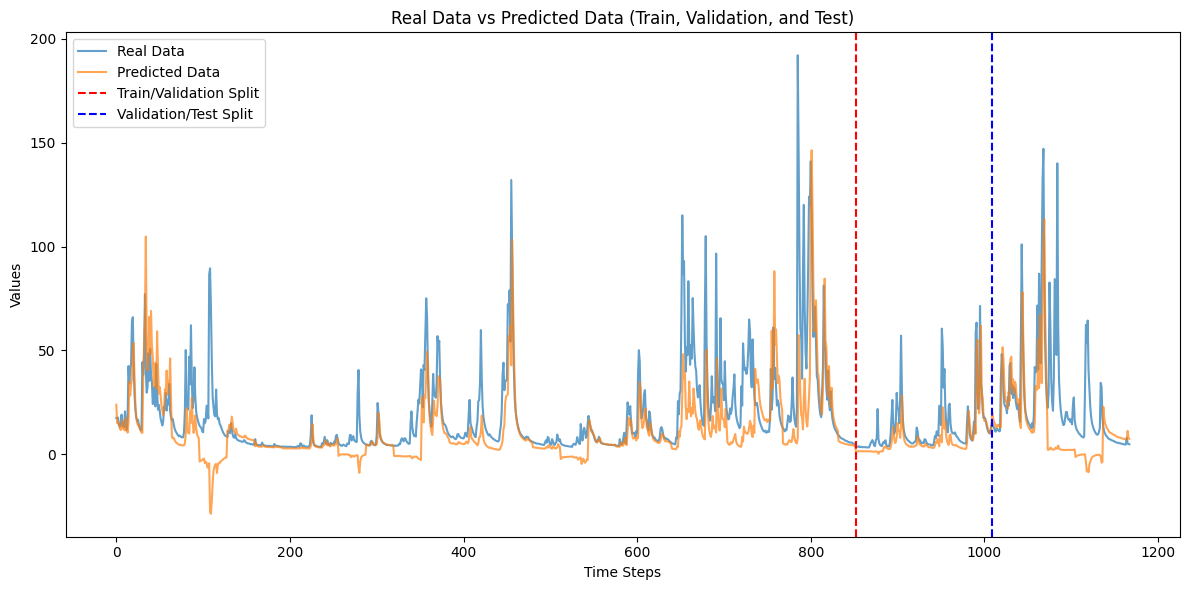

In [563]:
plot_combined_predictions(trainY, valY, testY, train_predict_ESN, val_predict_ESN, test_predict_ESN)

In [568]:
# Ejemplo de uso para el conjunto de prueba
calculate_errors(testY, test_predict_ESN)


MAE: 15.93674309328667
MSE: 655.6949636028523
RMSE: 25.60654142212205
MAPE: 60.21293647494981%
R²: -0.014764122947541036


(15.93674309328667,
 655.6949636028523,
 25.60654142212205,
 60.21293647494981,
 -0.014764122947541036)

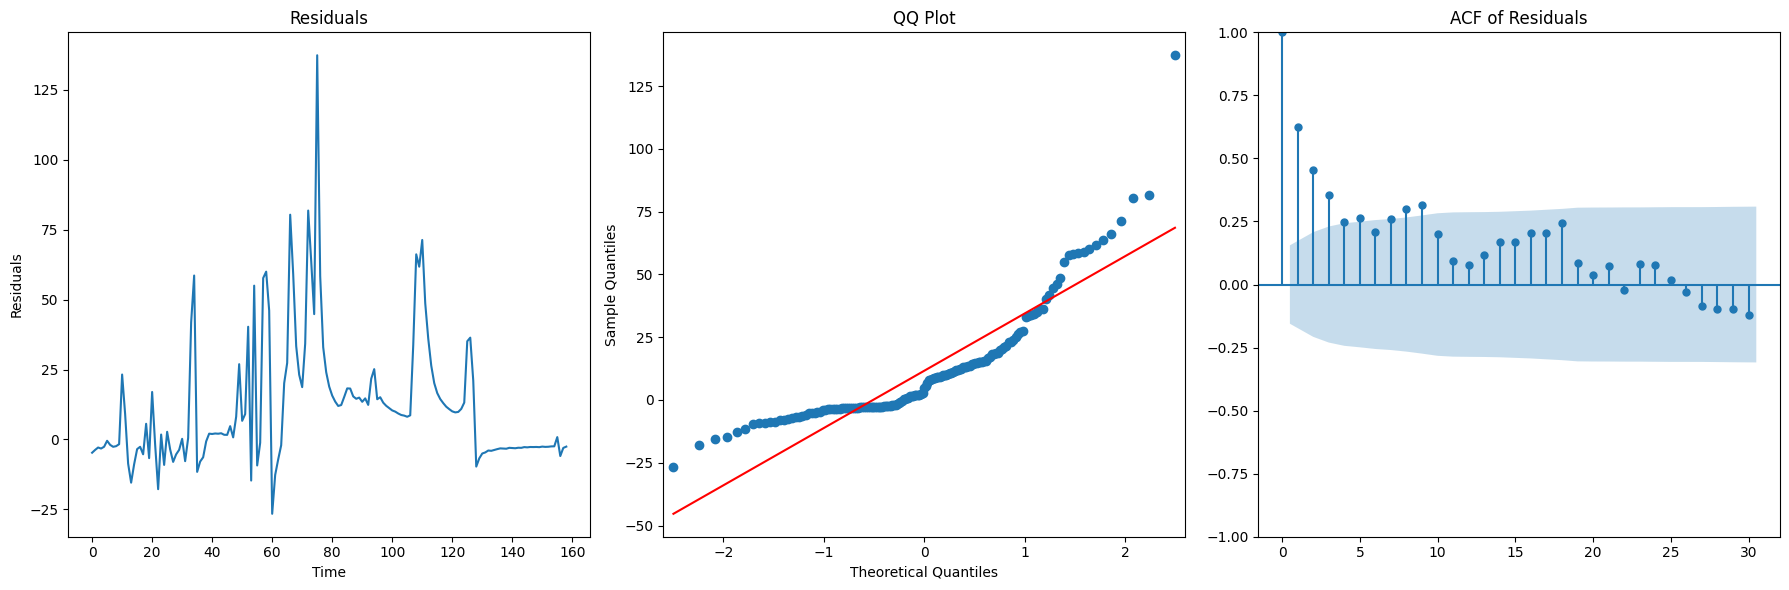

Ljung-Box Test p-value: 6.02375267419069e-17
Jarque-Bera Test p-value: 2.0078701427450465e-71


In [569]:
residuals = testY.reshape(-1, 1) - test_predict_ESN

# Generate plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Residual plot
axes[0].plot(residuals)
axes[0].set_title("Residuals")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Residuals")

# QQ plot
qqplot(residuals.flatten(), line='s', ax=axes[1])
axes[1].set_title("QQ Plot")

# ACF plot
plot_acf(residuals.flatten(), lags=30, ax=axes[2])
axes[2].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()

# Apply statistical tests
_, ljung_box_pval = q_stat(acf(residuals, fft=True, nlags=30)[1:], len(residuals))
_, jarque_bera_pval = jarque_bera(residuals)

# Show the results DataFrame and statistical test p-values
print("Ljung-Box Test p-value:", ljung_box_pval.mean())
print("Jarque-Bera Test p-value:", jarque_bera_pval)